In [1]:
# ============================================================
# PROJECT 2
# Failure-Driven Adaptive Augmentation for Robust
# Plant Disease Recognition
#
# STEP 1: DATASET INSPECTION
# ============================================================

from pathlib import Path
from collections import Counter
import os
import json
import pandas as pd

# ------------------------------------------------------------
# DATASET ROOT
# ------------------------------------------------------------

DATASET_ROOT = Path(r"C:\Users\cscpr\Downloads\random 2")

print("=" * 70)
print("DATASET INSPECTION")
print("=" * 70)

print(f"\nDataset path:")
print(DATASET_ROOT)

# ------------------------------------------------------------
# CHECK PATH
# ------------------------------------------------------------

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"\nDataset path does not exist:\n{DATASET_ROOT}\n"
        "Please check the path."
    )

print("\n✓ Dataset path exists.")

# ------------------------------------------------------------
# BASIC DIRECTORY CONTENT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP-LEVEL CONTENT")
print("=" * 70)

items = sorted(DATASET_ROOT.iterdir(), key=lambda x: x.name.lower())

for item in items:
    if item.is_dir():
        print(f"[DIR ]  {item.name}")
    else:
        size_mb = item.stat().st_size / (1024 * 1024)
        print(f"[FILE]  {item.name}  ({size_mb:.2f} MB)")

print(f"\nTotal top-level items: {len(items)}")
print(f"Directories: {sum(x.is_dir() for x in items)}")
print(f"Files: {sum(x.is_file() for x in items)}")

# ------------------------------------------------------------
# RECURSIVE FILE ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RECURSIVE DATASET ANALYSIS")
print("=" * 70)

all_files = [p for p in DATASET_ROOT.rglob("*") if p.is_file()]

print(f"\nTotal files found: {len(all_files):,}")

# File extensions
extension_counter = Counter(
    p.suffix.lower() if p.suffix else "[NO EXTENSION]"
    for p in all_files
)

print("\nFile extensions:")
for ext, count in extension_counter.most_common():
    print(f"  {ext:15s} : {count:,}")

# ------------------------------------------------------------
# IMAGE FILES
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

image_files = [
    p for p in all_files
    if p.suffix.lower() in IMAGE_EXTENSIONS
]

print("\n" + "=" * 70)
print("IMAGE DATASET")
print("=" * 70)

print(f"\nTotal image files: {len(image_files):,}")

# ------------------------------------------------------------
# DETECT POSSIBLE CLASS DIRECTORIES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("POSSIBLE CLASS STRUCTURE")
print("=" * 70)

top_level_dirs = [
    p for p in DATASET_ROOT.iterdir()
    if p.is_dir()
]

for directory in sorted(top_level_dirs):
    image_count = sum(
        1 for p in directory.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

    print(f"{directory.name:50s} : {image_count:,} images")

# ------------------------------------------------------------
# CLASS DETECTION
# ------------------------------------------------------------

# We identify directories that directly contain images.
class_directories = []

for directory in DATASET_ROOT.rglob("*"):
    if directory.is_dir():

        direct_images = [
            p for p in directory.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        if len(direct_images) > 0:
            class_directories.append(directory)

print("\n" + "=" * 70)
print("DIRECTORIES CONTAINING IMAGES")
print("=" * 70)

print(f"\nPossible class directories found: {len(class_directories)}")

for directory in sorted(class_directories):
    count = sum(
        1 for p in directory.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

    relative = directory.relative_to(DATASET_ROOT)

    print(f"{str(relative):60s} : {count:,}")

# ------------------------------------------------------------
# CLASS DISTRIBUTION
# ------------------------------------------------------------

class_counts = {}

for directory in class_directories:

    direct_images = [
        p for p in directory.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    class_name = directory.name

    class_counts[class_name] = len(direct_images)

if class_counts:

    class_df = pd.DataFrame(
        list(class_counts.items()),
        columns=["Class", "Image_Count"]
    ).sort_values(
        "Image_Count",
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 70)
    print("CLASS DISTRIBUTION")
    print("=" * 70)

    print(class_df.to_string(index=False))

    print("\nDataset statistics:")
    print(f"Number of classes : {len(class_df)}")
    print(f"Total images      : {class_df['Image_Count'].sum():,}")
    print(f"Minimum class     : {class_df['Image_Count'].min():,}")
    print(f"Maximum class     : {class_df['Image_Count'].max():,}")
    print(f"Mean/class        : {class_df['Image_Count'].mean():.2f}")
    print(f"Median/class      : {class_df['Image_Count'].median():.2f}")

else:
    print("\n⚠ No class directories containing images were detected.")

# ------------------------------------------------------------
# LOOK FOR EXISTING TRAIN / VALIDATION / TEST DIRECTORIES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAIN / VALIDATION / TEST STRUCTURE")
print("=" * 70)

split_keywords = {
    "train",
    "training",
    "val",
    "valid",
    "validation",
    "test",
    "testing"
}

possible_splits = []

for directory in DATASET_ROOT.rglob("*"):

    if directory.is_dir():

        name = directory.name.lower()

        if name in split_keywords:
            possible_splits.append(directory)

if possible_splits:

    print("\nPossible existing dataset splits:")

    for split in possible_splits:

        count = sum(
            1 for p in split.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )

        print(
            f"{str(split.relative_to(DATASET_ROOT)):60s} : "
            f"{count:,} images"
        )

else:
    print("\nNo explicit train/validation/test directories detected.")

# ------------------------------------------------------------
# LOOK FOR CSV / JSON / TXT METADATA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("METADATA FILES")
print("=" * 70)

metadata_extensions = {
    ".csv",
    ".json",
    ".txt",
    ".xlsx",
    ".xml"
}

metadata_files = [
    p for p in all_files
    if p.suffix.lower() in metadata_extensions
]

if metadata_files:

    for file in metadata_files:
        size_kb = file.stat().st_size / 1024
        print(
            f"{str(file.relative_to(DATASET_ROOT)):70s} "
            f"{size_kb:10.2f} KB"
        )

else:
    print("\nNo CSV/JSON/TXT/XLSX/XML metadata files found.")

# ------------------------------------------------------------
# SAMPLE IMAGE PATHS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SAMPLE IMAGE PATHS")
print("=" * 70)

for image_path in image_files[:20]:

    print(
        image_path.relative_to(DATASET_ROOT)
    )

# ------------------------------------------------------------
# SAVE INSPECTION REPORT
# ------------------------------------------------------------

report = {
    "dataset_root": str(DATASET_ROOT),
    "total_files": len(all_files),
    "total_images": len(image_files),
    "file_extensions": dict(extension_counter),
    "number_of_possible_classes": len(class_counts),
    "class_counts": class_counts,
    "possible_splits": [
        str(p.relative_to(DATASET_ROOT))
        for p in possible_splits
    ],
    "metadata_files": [
        str(p.relative_to(DATASET_ROOT))
        for p in metadata_files
    ]
}

REPORT_PATH = DATASET_ROOT / "dataset_inspection_report.json"

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=4)

print("\n" + "=" * 70)
print("INSPECTION COMPLETE")
print("=" * 70)

print(f"\nReport saved to:")
print(REPORT_PATH)

print("\nIMPORTANT:")
print("Do NOT start model training yet.")
print("Send me the complete output of this cell first.")

DATASET INSPECTION

Dataset path:
C:\Users\cscpr\Downloads\random 2

✓ Dataset path exists.

TOP-LEVEL CONTENT
[FILE]  code.ipynb  (0.10 MB)
[FILE]  dataset_inspection_report.json  (0.00 MB)
[DIR ]  models
[DIR ]  plantvillage dataset
[FILE]  plantvillage_color_stratified_split.csv  (9.41 MB)
[DIR ]  results

Total top-level items: 6
Directories: 3
Files: 3

RECURSIVE DATASET ANALYSIS

Total files found: 162,920

File extensions:
  .jpg            : 162,912
  .png            : 2
  .jpeg           : 2
  .ipynb          : 1
  .json           : 1
  .csv            : 1
  .pth            : 1

IMAGE DATASET

Total image files: 162,916

POSSIBLE CLASS STRUCTURE
models                                             : 0 images
plantvillage dataset                               : 162,916 images
results                                            : 0 images

DIRECTORIES CONTAINING IMAGES

Possible class directories found: 114
plantvillage dataset\color\Apple___Apple_scab                : 630
plantvil

In [2]:
# ============================================================
# PROJECT 2
# STEP 2: PREPARE COLOR DATASET + STRATIFIED SPLIT
# ============================================================

from pathlib import Path
from collections import Counter
import random
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("=" * 70)
print("STEP 2: DATASET PREPARATION")
print("=" * 70)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

DATASET_ROOT = Path(r"C:\Users\cscpr\Downloads\random 2")

COLOR_ROOT = DATASET_ROOT / "plantvillage dataset" / "color"

if not COLOR_ROOT.exists():
    raise FileNotFoundError(
        f"Color dataset was not found:\n{COLOR_ROOT}"
    )

print(f"\nColor dataset:")
print(COLOR_ROOT)

# ------------------------------------------------------------
# IMAGE EXTENSIONS
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

# ------------------------------------------------------------
# FIND CLASS DIRECTORIES
# ------------------------------------------------------------

class_directories = sorted(
    [
        p for p in COLOR_ROOT.iterdir()
        if p.is_dir()
    ],
    key=lambda x: x.name.lower()
)

print("\n" + "=" * 70)
print("CLASS VERIFICATION")
print("=" * 70)

print(f"\nNumber of classes: {len(class_directories)}")

if len(class_directories) != 38:
    print(
        "\nWARNING:"
        f" Expected 38 classes, but found {len(class_directories)}."
    )

# ------------------------------------------------------------
# BUILD IMAGE INDEX
# ------------------------------------------------------------

records = []

for class_dir in class_directories:

    class_name = class_dir.name

    images = sorted(
        [
            p for p in class_dir.iterdir()
            if p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        ],
        key=lambda x: x.name.lower()
    )

    for image_path in images:

        records.append(
            {
                "path": str(image_path),
                "class_name": class_name
            }
        )

df = pd.DataFrame(records)

# ------------------------------------------------------------
# BASIC DATASET STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COLOR DATASET STATISTICS")
print("=" * 70)

print(f"\nTotal images: {len(df):,}")
print(f"Total classes: {df['class_name'].nunique()}")

class_distribution = (
    df["class_name"]
    .value_counts()
    .sort_index()
)

print("\nClass distribution:")

for class_name, count in class_distribution.items():
    print(f"{class_name:60s} : {count:,}")

# ------------------------------------------------------------
# CHECK FOR DUPLICATE PATHS
# ------------------------------------------------------------

duplicate_paths = df["path"].duplicated().sum()

print("\nDuplicate file paths:", duplicate_paths)

if duplicate_paths > 0:
    raise RuntimeError(
        "Duplicate image paths detected."
    )

# ------------------------------------------------------------
# STRATIFIED SPLIT
# ------------------------------------------------------------

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(
    TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0
) < 1e-8

print("\n" + "=" * 70)
print("CREATING STRATIFIED SPLIT")
print("=" * 70)

split_records = []

for class_name, class_df in df.groupby(
    "class_name",
    sort=True
):

    class_df = class_df.sample(
        frac=1.0,
        random_state=SEED
    ).reset_index(drop=True)

    n = len(class_df)

    # --------------------------------------------------------
    # Calculate split boundaries
    # --------------------------------------------------------

    n_train = int(round(n * TRAIN_RATIO))
    n_val = int(round(n * VAL_RATIO))

    # Guarantee at least one sample in each split
    if n >= 3:

        n_train = max(1, n_train)
        n_val = max(1, n_val)

        if n_train + n_val >= n:
            n_val = max(1, n - n_train - 1)

    n_test = n - n_train - n_val

    if n_test < 1:
        raise RuntimeError(
            f"Unable to create test split for class: {class_name}"
        )

    # --------------------------------------------------------
    # Assign split labels
    # --------------------------------------------------------

    train_part = class_df.iloc[:n_train].copy()
    val_part = class_df.iloc[
        n_train:n_train + n_val
    ].copy()
    test_part = class_df.iloc[
        n_train + n_val:
    ].copy()

    train_part["split"] = "train"
    val_part["split"] = "validation"
    test_part["split"] = "test"

    split_records.extend(
        train_part.to_dict("records")
    )

    split_records.extend(
        val_part.to_dict("records")
    )

    split_records.extend(
        test_part.to_dict("records")
    )

split_df = pd.DataFrame(split_records)

# ------------------------------------------------------------
# SHUFFLE FINAL INDEX
# ------------------------------------------------------------

split_df = split_df.sample(
    frac=1.0,
    random_state=SEED
).reset_index(drop=True)

# ------------------------------------------------------------
# VERIFY SPLIT COUNTS
# ------------------------------------------------------------

print("\nOverall split counts:")

print(
    split_df["split"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# VERIFY CLASS-WISE SPLIT
# ------------------------------------------------------------

class_split_table = pd.crosstab(
    split_df["class_name"],
    split_df["split"]
)

# Ensure all expected columns exist
for column in ["train", "validation", "test"]:
    if column not in class_split_table.columns:
        class_split_table[column] = 0

class_split_table = class_split_table[
    ["train", "validation", "test"]
]

print("\n" + "=" * 70)
print("CLASS-WISE SPLIT")
print("=" * 70)

print(class_split_table.to_string())

# ------------------------------------------------------------
# VERIFY NO PATH OVERLAP
# ------------------------------------------------------------

train_paths = set(
    split_df.loc[
        split_df["split"] == "train",
        "path"
    ]
)

val_paths = set(
    split_df.loc[
        split_df["split"] == "validation",
        "path"
    ]
)

test_paths = set(
    split_df.loc[
        split_df["split"] == "test",
        "path"
    ]
)

print("\n" + "=" * 70)
print("LEAKAGE CHECK")
print("=" * 70)

print(
    "Train ∩ Validation:",
    len(train_paths.intersection(val_paths))
)

print(
    "Train ∩ Test:",
    len(train_paths.intersection(test_paths))
)

print(
    "Validation ∩ Test:",
    len(val_paths.intersection(test_paths))
)

if (
    train_paths.intersection(val_paths)
    or train_paths.intersection(test_paths)
    or val_paths.intersection(test_paths)
):
    raise RuntimeError(
        "DATA LEAKAGE DETECTED: overlapping image paths."
    )

print("\n✓ No image-path overlap detected.")

# ------------------------------------------------------------
# VERIFY EVERY IMAGE HAS ONE SPLIT
# ------------------------------------------------------------

split_counts_per_path = (
    split_df.groupby("path")["split"]
    .nunique()
)

bad_paths = split_counts_per_path[
    split_counts_per_path != 1
]

if len(bad_paths) > 0:
    raise RuntimeError(
        "Some images belong to multiple splits."
    )

print("✓ Every image belongs to exactly one split.")

# ------------------------------------------------------------
# VERIFY TOTALS
# ------------------------------------------------------------

if len(split_df) != len(df):
    raise RuntimeError(
        "Split dataset size does not match original dataset."
    )

print("✓ Split contains every color image exactly once.")

# ------------------------------------------------------------
# SAVE SPLIT INDEX
# ------------------------------------------------------------

SPLIT_FILE = (
    DATASET_ROOT /
    "plantvillage_color_stratified_split.csv"
)

split_df.to_csv(
    SPLIT_FILE,
    index=False,
    encoding="utf-8"
)

print("\n" + "=" * 70)
print("SPLIT SAVED")
print("=" * 70)

print(f"\nSaved to:")
print(SPLIT_FILE)

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

print(f"Classes       : {split_df['class_name'].nunique()}")
print(f"Total images  : {len(split_df):,}")

for split_name in ["train", "validation", "test"]:

    count = (
        split_df["split"] == split_name
    ).sum()

    percentage = (
        count / len(split_df)
    ) * 100

    print(
        f"{split_name.capitalize():12s}: "
        f"{count:6,} ({percentage:.2f}%)"
    )

print("\n✓ Dataset preparation completed.")
print("✓ No model training performed.")

STEP 2: DATASET PREPARATION

Color dataset:
C:\Users\cscpr\Downloads\random 2\plantvillage dataset\color

CLASS VERIFICATION

Number of classes: 38

COLOR DATASET STATISTICS

Total images: 54,305
Total classes: 38

Class distribution:
Apple___Apple_scab                                           : 630
Apple___Black_rot                                            : 621
Apple___Cedar_apple_rust                                     : 275
Apple___healthy                                              : 1,645
Blueberry___healthy                                          : 1,502
Cherry_(including_sour)___Powdery_mildew                     : 1,052
Cherry_(including_sour)___healthy                            : 854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot           : 513
Corn_(maize)___Common_rust_                                  : 1,192
Corn_(maize)___Northern_Leaf_Blight                          : 985
Corn_(maize)___healthy                                       : 1,162
Grape___Black_rot 

In [3]:
# ============================================================
# PROJECT 2
# STEP 3: BASELINE MODEL CONFIGURATION
# ============================================================

import os
import random
import time
import copy
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image

import torchvision
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("BASELINE MODEL CONFIGURATION")
print("=" * 70)

print(f"\nPyTorch version : {torch.__version__}")
print(f"Torchvision     : {torchvision.__version__}")
print(f"Device          : {DEVICE}")

if torch.cuda.is_available():

    print(f"GPU             : {torch.cuda.get_device_name(0)}")

    gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    print(
        f"GPU memory      : {gpu_memory:.2f} GB"
    )

else:
    print("\nWARNING: CUDA is not available.")
    print("Training will use CPU and may be considerably slower.")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

DATASET_ROOT = Path(
    r"C:\Users\cscpr\Downloads\random 2"
)

SPLIT_FILE = (
    DATASET_ROOT /
    "plantvillage_color_stratified_split.csv"
)

MODEL_DIR = DATASET_ROOT / "models"
RESULTS_DIR = DATASET_ROOT / "results"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

if not SPLIT_FILE.exists():
    raise FileNotFoundError(
        f"Split file not found:\n{SPLIT_FILE}"
    )

print(f"\nSplit file:")
print(SPLIT_FILE)

print(f"\nModel directory:")
print(MODEL_DIR)

print(f"\nResults directory:")
print(RESULTS_DIR)

# ------------------------------------------------------------
# HYPERPARAMETERS
# ------------------------------------------------------------

NUM_CLASSES = 38

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 0

NUM_EPOCHS = 15

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

PATIENCE = 4

print("\n" + "=" * 70)
print("HYPERPARAMETERS")
print("=" * 70)

config = {
    "seed": SEED,
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE
}

for key, value in config.items():
    print(f"{key:20s}: {value}")

BASELINE MODEL CONFIGURATION

PyTorch version : 2.13.0+cu132
Torchvision     : 0.28.0+cu132
Device          : cuda
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU
GPU memory      : 6.00 GB

Split file:
C:\Users\cscpr\Downloads\random 2\plantvillage_color_stratified_split.csv

Model directory:
C:\Users\cscpr\Downloads\random 2\models

Results directory:
C:\Users\cscpr\Downloads\random 2\results

HYPERPARAMETERS
seed                : 42
num_classes         : 38
image_size          : 224
batch_size          : 32
num_workers         : 0
num_epochs          : 15
learning_rate       : 0.0001
weight_decay        : 0.0001
patience            : 4


In [4]:
# ============================================================
# STEP 4: LOAD SPLIT INDEX + CLASS MAPPING
# ============================================================

print("=" * 70)
print("LOADING DATA SPLIT")
print("=" * 70)

split_df = pd.read_csv(
    SPLIT_FILE
)

# ------------------------------------------------------------
# BASIC VALIDATION
# ------------------------------------------------------------

required_columns = {
    "path",
    "class_name",
    "split"
}

missing_columns = (
    required_columns -
    set(split_df.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

# ------------------------------------------------------------
# CLASS MAPPING
# ------------------------------------------------------------

class_names = sorted(
    split_df["class_name"].unique()
)

if len(class_names) != NUM_CLASSES:
    raise ValueError(
        f"Expected {NUM_CLASSES} classes, "
        f"but found {len(class_names)}."
    )

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

split_df["label"] = (
    split_df["class_name"]
    .map(class_to_idx)
)

# ------------------------------------------------------------
# DISPLAY CLASS MAPPING
# ------------------------------------------------------------

print("\nClass mapping:")

for idx in range(NUM_CLASSES):
    print(
        f"{idx:2d} -> {idx_to_class[idx]}"
    )

# ------------------------------------------------------------
# SPLIT SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SPLIT SUMMARY")
print("=" * 70)

for split_name in [
    "train",
    "validation",
    "test"
]:

    subset = split_df[
        split_df["split"] == split_name
    ]

    print(
        f"{split_name:12s}: "
        f"{len(subset):,} images"
    )

# ------------------------------------------------------------
# CHECK IMAGE PATHS
# ------------------------------------------------------------

missing_files = []

for path in split_df["path"].sample(
    min(100, len(split_df)),
    random_state=SEED
):

    if not Path(path).exists():
        missing_files.append(path)

if missing_files:

    print("\nWARNING:")
    print(
        f"{len(missing_files)} sampled paths do not exist."
    )

else:

    print(
        "\n✓ Sampled image paths successfully verified."
    )

LOADING DATA SPLIT

Class mapping:
 0 -> Apple___Apple_scab
 1 -> Apple___Black_rot
 2 -> Apple___Cedar_apple_rust
 3 -> Apple___healthy
 4 -> Blueberry___healthy
 5 -> Cherry_(including_sour)___Powdery_mildew
 6 -> Cherry_(including_sour)___healthy
 7 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 8 -> Corn_(maize)___Common_rust_
 9 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blight
22 -> Potato___healthy
23 -> Raspberry___healthy
24 -> Soybean___healthy
25 -> Squash___Powdery_mildew
26 -> Strawberry___Leaf_scorch
27 -> Strawberry___healthy
28 -> Tomato___Bacterial_spot
29 -> Tomato___Early_blight
30 -> Tomato___Late_b

In [5]:
# ============================================================
# STEP 5: PYTORCH DATASET
# ============================================================

class PlantVillageDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["path"]
        label = int(row["label"])

        try:
            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as error:
            raise RuntimeError(
                f"Could not load image:\n"
                f"{image_path}\n"
                f"Error: {error}"
            )

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [6]:
# ============================================================
# STEP 6: IMAGE TRANSFORMS
# ============================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

# ------------------------------------------------------------
# TRAIN TRANSFORM
# ------------------------------------------------------------

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# ------------------------------------------------------------
# VALIDATION / TEST
# ------------------------------------------------------------

eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("=" * 70)
print("TRANSFORMS READY")
print("=" * 70)

print("\nTraining transform:")
print(train_transform)

print("\nEvaluation transform:")
print(eval_transform)

TRANSFORMS READY

Training transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.85, 1.15), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Evaluation transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [7]:
# ============================================================
# STEP 7: CREATE DATASETS AND DATALOADERS
# ============================================================

train_df = split_df[
    split_df["split"] == "train"
].copy()

val_df = split_df[
    split_df["split"] == "validation"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()

# ------------------------------------------------------------
# DATASETS
# ------------------------------------------------------------

train_dataset = PlantVillageDataset(
    train_df,
    transform=train_transform
)

val_dataset = PlantVillageDataset(
    val_df,
    transform=eval_transform
)

test_dataset = PlantVillageDataset(
    test_df,
    transform=eval_transform
)

# ------------------------------------------------------------
# DATALOADERS
# ------------------------------------------------------------

pin_memory = (
    DEVICE.type == "cuda"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print("=" * 70)
print("DATALOADERS CREATED")
print("=" * 70)

print(
    f"\nTraining images   : {len(train_dataset):,}"
)

print(
    f"Validation images : {len(val_dataset):,}"
)

print(
    f"Test images       : {len(test_dataset):,}"
)

print(
    f"\nTraining batches   : {len(train_loader):,}"
)

print(
    f"Validation batches : {len(val_loader):,}"
)

print(
    f"Test batches       : {len(test_loader):,}"
)

# ------------------------------------------------------------
# BATCH TEST
# ------------------------------------------------------------

images, labels = next(
    iter(train_loader)
)

print("\nFirst training batch:")
print(
    f"Image tensor shape : {images.shape}"
)
print(
    f"Label tensor shape : {labels.shape}"
)
print(
    f"Image dtype        : {images.dtype}"
)
print(
    f"Label dtype        : {labels.dtype}"
)

print("\n✓ DataLoader test successful.")

DATALOADERS CREATED

Training images   : 38,012
Validation images : 8,146
Test images       : 8,147

Training batches   : 1,188
Validation batches : 255
Test batches       : 255

First training batch:
Image tensor shape : torch.Size([32, 3, 224, 224])
Label tensor shape : torch.Size([32])
Image dtype        : torch.float32
Label dtype        : torch.int64

✓ DataLoader test successful.


In [8]:
# ============================================================
# STEP 8: RESNET-50 BASELINE MODEL
# ============================================================

print("=" * 70)
print("BUILDING RESNET-50")
print("=" * 70)

# ------------------------------------------------------------
# LOAD PRETRAINED RESNET-50
# ------------------------------------------------------------

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

weights = ResNet50_Weights.DEFAULT

model = resnet50(
    weights=weights
)

# ------------------------------------------------------------
# REPLACE FINAL CLASSIFIER
# ------------------------------------------------------------

in_features = model.fc.in_features

model.fc = nn.Linear(
    in_features,
    NUM_CLASSES
)

# ------------------------------------------------------------
# MOVE MODEL TO GPU
# ------------------------------------------------------------

model = model.to(DEVICE)

# ------------------------------------------------------------
# MODEL INFORMATION
# ------------------------------------------------------------

print("\nFinal classification layer:")
print(model.fc)

# ------------------------------------------------------------
# PARAMETER COUNTS
# ------------------------------------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("\n" + "=" * 70)
print("MODEL PARAMETERS")
print("=" * 70)

print(
    f"\nTotal parameters     : "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_parameters:,}"
)

# ------------------------------------------------------------
# MODEL SIZE
# ------------------------------------------------------------

parameter_memory_mb = (
    total_parameters * 4
) / (1024 ** 2)

print(
    f"Approx. FP32 parameter memory : "
    f"{parameter_memory_mb:.2f} MB"
)

print("\n✓ ResNet-50 ready.")

BUILDING RESNET-50

Final classification layer:
Linear(in_features=2048, out_features=38, bias=True)

MODEL PARAMETERS

Total parameters     : 23,585,894
Trainable parameters : 23,585,894
Approx. FP32 parameter memory : 89.97 MB

✓ ResNet-50 ready.


In [13]:
# ============================================================
# STEP 9: TRAIN RESNET-50 BASELINE
# ============================================================

import time
import copy

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# LEARNING-RATE SCHEDULER
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-7
)

# ------------------------------------------------------------
# MIXED PRECISION
# ------------------------------------------------------------

use_amp = DEVICE.type == "cuda"

if use_amp:
    scaler = torch.amp.GradScaler("cuda")
else:
    scaler = None

# ------------------------------------------------------------
# TRAINING HISTORY
# ------------------------------------------------------------

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_balanced_accuracy": [],
    "val_macro_f1": [],
    "learning_rate": [],
    "epoch_time_seconds": []
}

# ------------------------------------------------------------
# BEST MODEL TRACKING
# ------------------------------------------------------------

best_model_state = copy.deepcopy(
    model.state_dict()
)

best_val_f1 = -1.0
best_epoch = 0

epochs_without_improvement = 0

BEST_MODEL_PATH = (
    MODEL_DIR /
    "resnet50_baseline_best.pth"
)

print("=" * 70)
print("RESNET-50 BASELINE TRAINING")
print("=" * 70)

print(f"\nEpochs           : {NUM_EPOCHS}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Learning rate    : {LEARNING_RATE}")
print(f"Weight decay     : {WEIGHT_DECAY}")
print(f"AMP enabled      : {use_amp}")
print(f"Early stopping   : {PATIENCE} epochs")

# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_running_loss = 0.0

    train_predictions = []
    train_targets = []

    for images, labels in train_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # FORWARD + LOSS
        # ----------------------------------------------------

        if use_amp:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            scaler.scale(
                loss
            ).backward()

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

        # ----------------------------------------------------
        # TRACK LOSS
        # ----------------------------------------------------

        train_running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = (
            outputs
            .argmax(dim=1)
            .detach()
            .cpu()
            .numpy()
        )

        targets = (
            labels
            .detach()
            .cpu()
            .numpy()
        )

        train_predictions.extend(
            predictions
        )

        train_targets.extend(
            targets
        )

    # --------------------------------------------------------
    # TRAIN METRICS
    # --------------------------------------------------------

    train_loss = (
        train_running_loss /
        len(train_dataset)
    )

    train_accuracy = accuracy_score(
        train_targets,
        train_predictions
    )

    train_macro_f1 = f1_score(
        train_targets,
        train_predictions,
        average="macro",
        zero_division=0
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0

    val_predictions = []
    val_targets = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            if use_amp:

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):

                    outputs = model(images)

                    loss = criterion(
                        outputs,
                        labels
                    )

            else:

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            val_running_loss += (
                loss.item() *
                images.size(0)
            )

            predictions = (
                outputs
                .argmax(dim=1)
                .cpu()
                .numpy()
            )

            targets = (
                labels
                .cpu()
                .numpy()
            )

            val_predictions.extend(
                predictions
            )

            val_targets.extend(
                targets
            )

    # --------------------------------------------------------
    # VALIDATION METRICS
    # --------------------------------------------------------

    val_loss = (
        val_running_loss /
        len(val_dataset)
    )

    val_accuracy = accuracy_score(
        val_targets,
        val_predictions
    )

    val_balanced_accuracy = (
        balanced_accuracy_score(
            val_targets,
            val_predictions
        )
    )

    val_macro_f1 = f1_score(
        val_targets,
        val_predictions,
        average="macro",
        zero_division=0
    )

    # --------------------------------------------------------
    # SCHEDULER
    # --------------------------------------------------------

    scheduler.step(
        val_macro_f1
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # --------------------------------------------------------
    # EPOCH TIME
    # --------------------------------------------------------

    epoch_time = (
        time.time() -
        epoch_start
    )

    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    history["epoch"].append(
        epoch
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["train_macro_f1"].append(
        train_macro_f1
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["val_balanced_accuracy"].append(
        val_balanced_accuracy
    )

    history["val_macro_f1"].append(
        val_macro_f1
    )

    history["learning_rate"].append(
        current_lr
    )

    history["epoch_time_seconds"].append(
        epoch_time
    )

    # --------------------------------------------------------
    # CHECKPOINT
    # --------------------------------------------------------

    improved = (
        val_macro_f1 >
        best_val_f1
    )

    if improved:

        best_val_f1 = val_macro_f1

        best_epoch = epoch

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_macro_f1": val_macro_f1,
                "class_names": class_names,
                "class_to_idx": class_to_idx,
                "seed": SEED
            },
            BEST_MODEL_PATH
        )

        epochs_without_improvement = 0

        checkpoint_status = "✓ BEST"

    else:

        epochs_without_improvement += 1

        checkpoint_status = ""

    # --------------------------------------------------------
    # PRINT EPOCH
    # --------------------------------------------------------

    print(
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS} "
        f"{checkpoint_status}"
    )

    print(
        f"  Train Loss       : {train_loss:.4f}"
    )

    print(
        f"  Train Accuracy   : "
        f"{train_accuracy:.4f}"
    )

    print(
        f"  Train Macro-F1   : "
        f"{train_macro_f1:.4f}"
    )

    print(
        f"  Val Loss         : {val_loss:.4f}"
    )

    print(
        f"  Val Accuracy     : "
        f"{val_accuracy:.4f}"
    )

    print(
        f"  Val Balanced Acc : "
        f"{val_balanced_accuracy:.4f}"
    )

    print(
        f"  Val Macro-F1     : "
        f"{val_macro_f1:.4f}"
    )

    print(
        f"  Learning Rate    : "
        f"{current_lr:.7f}"
    )

    print(
        f"  Time             : "
        f"{epoch_time:.1f}s"
    )

    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping triggered "
            f"after epoch {epoch}."
        )

        break

# ------------------------------------------------------------
# RESTORE BEST MODEL
# ------------------------------------------------------------

model.load_state_dict(
    best_model_state
)

print("\n" + "=" * 70)
print("BASELINE TRAINING COMPLETE")
print("=" * 70)

print(
    f"\nBest epoch      : {best_epoch}"
)

print(
    f"Best Val Macro-F1 : "
    f"{best_val_f1:.4f}"
)

print(
    f"\nBest model saved to:"
)

print(BEST_MODEL_PATH)

RESNET-50 BASELINE TRAINING

Epochs           : 15
Batch size       : 32
Learning rate    : 0.0001
Weight decay     : 0.0001
AMP enabled      : True
Early stopping   : 4 epochs

Epoch 01/15 ✓ BEST
  Train Loss       : 0.3143
  Train Accuracy   : 0.9193
  Train Macro-F1   : 0.9028
  Val Loss         : 0.0491
  Val Accuracy     : 0.9849
  Val Balanced Acc : 0.9767
  Val Macro-F1     : 0.9754
  Learning Rate    : 0.0001000
  Time             : 583.2s

Epoch 02/15 ✓ BEST
  Train Loss       : 0.0435
  Train Accuracy   : 0.9873
  Train Macro-F1   : 0.9829
  Val Loss         : 0.0445
  Val Accuracy     : 0.9856
  Val Balanced Acc : 0.9826
  Val Macro-F1     : 0.9820
  Learning Rate    : 0.0001000
  Time             : 639.1s

Epoch 03/15 ✓ BEST
  Train Loss       : 0.0300
  Train Accuracy   : 0.9902
  Train Macro-F1   : 0.9869
  Val Loss         : 0.0365
  Val Accuracy     : 0.9888
  Val Balanced Acc : 0.9860
  Val Macro-F1     : 0.9849
  Learning Rate    : 0.0001000
  Time             : 698.7

In [12]:
BEST_MODEL_PATH = Path(
    r"C:\Users\cscpr\Downloads\random 2\models\resnet50_baseline_best.pth"
)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("✓ Best ResNet-50 checkpoint loaded.")
print(f"Checkpoint epoch: {checkpoint['epoch']}")
print(
    f"Validation Macro-F1: "
    f"{checkpoint['val_macro_f1']:.4f}"
)

✓ Best ResNet-50 checkpoint loaded.
Checkpoint epoch: 14
Validation Macro-F1: 0.9978


In [15]:
# ============================================================
# STEP 12: CLEAN TEST-SET EVALUATION
# FULLY SELF-CONTAINED
# ============================================================

import time
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

BEST_MODEL_PATH = Path(
    r"C:\Users\cscpr\Downloads\random 2\models\resnet50_baseline_best.pth"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

use_amp = DEVICE.type == "cuda"

# Create loss function locally.
criterion = nn.CrossEntropyLoss()

print("=" * 70)
print("RESNET-50 BASELINE — CLEAN TEST EVALUATION")
print("=" * 70)

print(f"\nDevice       : {DEVICE}")
print(f"AMP enabled  : {use_amp}")

# ------------------------------------------------------------
# LOAD BEST CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("\n✓ Loaded checkpoint:")
print(BEST_MODEL_PATH)

print(
    f"\nCheckpoint epoch       : "
    f"{checkpoint['epoch']}"
)

print(
    f"Checkpoint Val Macro-F1: "
    f"{checkpoint['val_macro_f1']:.4f}"
)

# ------------------------------------------------------------
# TEST INFERENCE
# ------------------------------------------------------------

test_predictions = []
test_targets = []

test_running_loss = 0.0

start_time = time.time()

with torch.no_grad():

    for batch_index, (images, labels) in enumerate(
        test_loader
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        if use_amp:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

        else:

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        test_running_loss += (
            loss.item() *
            images.size(0)
        )

        # ----------------------------------------------------
        # PREDICTIONS
        # ----------------------------------------------------

        predictions = (
            outputs
            .argmax(dim=1)
            .cpu()
            .numpy()
        )

        targets = (
            labels
            .cpu()
            .numpy()
        )

        test_predictions.extend(
            predictions
        )

        test_targets.extend(
            targets
        )

        # Progress
        if (
            (batch_index + 1) % 50 == 0
            or
            (batch_index + 1) == len(test_loader)
        ):

            print(
                f"Processed "
                f"{batch_index + 1:,}/"
                f"{len(test_loader):,} batches",
                end="\r"
            )

# ------------------------------------------------------------
# CONVERT TO NUMPY
# ------------------------------------------------------------

test_predictions = np.asarray(
    test_predictions
)

test_targets = np.asarray(
    test_targets
)

test_time = (
    time.time() -
    start_time
)

# ------------------------------------------------------------
# SAFETY CHECK
# ------------------------------------------------------------

assert len(test_predictions) == len(test_dataset)

assert len(test_targets) == len(test_dataset)

print(
    f"\n\n✓ Evaluated "
    f"{len(test_targets):,} test images."
)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

test_loss = (
    test_running_loss /
    len(test_dataset)
)

test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

test_balanced_accuracy = (
    balanced_accuracy_score(
        test_targets,
        test_predictions
    )
)

test_macro_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

test_weighted_f1 = f1_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLEAN TEST RESULTS")
print("=" * 70)

print(
    f"\nTest images            : "
    f"{len(test_dataset):,}"
)

print(
    f"Test Loss              : "
    f"{test_loss:.6f}"
)

print(
    f"Test Accuracy          : "
    f"{test_accuracy:.4%}"
)

print(
    f"Test Balanced Accuracy : "
    f"{test_balanced_accuracy:.4%}"
)

print(
    f"Test Macro-F1          : "
    f"{test_macro_f1:.4%}"
)

print(
    f"Test Weighted-F1       : "
    f"{test_weighted_f1:.4%}"
)

print(
    f"Inference time         : "
    f"{test_time:.1f} seconds"
)

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

report = classification_report(
    test_targets,
    test_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(report)

# ------------------------------------------------------------
# SAVE TEST RESULTS
# ------------------------------------------------------------

RESULTS_DIR = Path(
    r"C:\Users\cscpr\Downloads\random 2\results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TEST_REPORT_PATH = (
    RESULTS_DIR /
    "resnet50_baseline_clean_test_report.txt"
)

with open(
    TEST_REPORT_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "RESNET-50 BASELINE CLEAN TEST EVALUATION\n"
    )

    file.write("=" * 70 + "\n\n")

    file.write(
        f"Checkpoint epoch       : "
        f"{checkpoint['epoch']}\n"
    )

    file.write(
        f"Validation Macro-F1    : "
        f"{checkpoint['val_macro_f1']:.6f}\n\n"
    )

    file.write(
        f"Test Loss              : "
        f"{test_loss:.6f}\n"
    )

    file.write(
        f"Test Accuracy          : "
        f"{test_accuracy:.6f}\n"
    )

    file.write(
        f"Test Balanced Accuracy : "
        f"{test_balanced_accuracy:.6f}\n"
    )

    file.write(
        f"Test Macro-F1          : "
        f"{test_macro_f1:.6f}\n"
    )

    file.write(
        f"Test Weighted-F1       : "
        f"{test_weighted_f1:.6f}\n\n"
    )

    file.write(report)

print(
    f"\n✓ Report saved to:"
)

print(TEST_REPORT_PATH)

RESNET-50 BASELINE — CLEAN TEST EVALUATION

Device       : cuda
AMP enabled  : True

✓ Loaded checkpoint:
C:\Users\cscpr\Downloads\random 2\models\resnet50_baseline_best.pth

Checkpoint epoch       : 14
Checkpoint Val Macro-F1: 0.9978
Processed 255/255 batches

✓ Evaluated 8,147 test images.

CLEAN TEST RESULTS

Test images            : 8,147
Test Loss              : 0.006134
Test Accuracy          : 99.8650%
Test Balanced Accuracy : 99.7889%
Test Macro-F1          : 99.7282%
Test Weighted-F1       : 99.8653%
Inference time         : 59.1 seconds

CLASSIFICATION REPORT
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000        95
                                 Apple___Black_rot     1.0000    1.0000    1.0000        93
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        42
                                   Apple___healthy     

In [17]:
# ============================================================
# STEP 14A: TEST DATASET PIPELINE DIAGNOSTIC
# ============================================================

from pathlib import Path
import torch
from PIL import Image

print("=" * 70)
print("TEST DATASET PIPELINE DIAGNOSTIC")
print("=" * 70)

print("\nDataset type:")
print(type(test_dataset))

print("\nDataset length:")
print(len(test_dataset))

print("\nDataset attributes:")
print([
    x for x in dir(test_dataset)
    if not x.startswith("_")
][:100])

print("\n" + "=" * 70)
print("CHECKING COMMON DATASET ATTRIBUTES")
print("=" * 70)

for attr in [
    "transform",
    "target_transform",
    "samples",
    "imgs",
    "targets",
    "data",
    "dataset",
    "csv_file",
    "split_file",
    "paths",
    "image_paths"
]:

    if hasattr(test_dataset, attr):

        value = getattr(
            test_dataset,
            attr
        )

        print(
            f"\n{attr}:"
        )

        print(
            f"  type = {type(value)}"
        )

        try:

            print(
                f"  length = {len(value)}"
            )

        except Exception:

            pass

        print(
            f"  value = "
            f"{str(value)[:1000]}"
        )

# ------------------------------------------------------------
# INSPECT FIRST SAMPLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIRST TEST SAMPLE")
print("=" * 70)

sample = test_dataset[0]

print(
    "\nSample type:"
)

print(
    type(sample)
)

if isinstance(sample, (tuple, list)):

    print(
        "\nNumber of returned elements:",
        len(sample)
    )

    for i, item in enumerate(sample):

        print(
            f"\nElement {i}:"
        )

        print(
            f"  Type: {type(item)}"
        )

        if torch.is_tensor(item):

            print(
                f"  Shape: {tuple(item.shape)}"
            )

            print(
                f"  dtype: {item.dtype}"
            )

            print(
                f"  min: {item.min().item():.6f}"
            )

            print(
                f"  max: {item.max().item():.6f}"
            )

        elif isinstance(
            item,
            Image.Image
        ):

            print(
                f"  PIL size: {item.size}"
            )

            print(
                f"  PIL mode: {item.mode}"
            )

        else:

            print(
                f"  Value: {str(item)[:500]}"
            )

else:

    print(
        "Sample:",
        str(sample)[:1000]
    )

# ------------------------------------------------------------
# CHECK TRANSFORM
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TEST TRANSFORM")
print("=" * 70)

if hasattr(
    test_dataset,
    "transform"
):

    print(
        test_dataset.transform
    )

else:

    print(
        "No direct .transform attribute."
    )

# ------------------------------------------------------------
# CHECK UNDERLYING DATASET
# ------------------------------------------------------------

if hasattr(
    test_dataset,
    "dataset"
):

    underlying = test_dataset.dataset

    print("\n" + "=" * 70)
    print("UNDERLYING DATASET")
    print("=" * 70)

    print(
        "Type:",
        type(underlying)
    )

    print(
        "Length:",
        len(underlying)
    )

    for attr in [
        "transform",
        "samples",
        "imgs",
        "targets",
        "data"
    ]:

        if hasattr(
            underlying,
            attr
        ):

            value = getattr(
                underlying,
                attr
            )

            print(
                f"\n{attr}:"
            )

            print(
                f"  type = {type(value)}"
            )

            try:

                print(
                    f"  length = {len(value)}"
                )

            except Exception:

                pass

            print(
                f"  value = "
                f"{str(value)[:1000]}"
            )

print("\n" + "=" * 70)
print("DIAGNOSTIC COMPLETE")
print("=" * 70)

TEST DATASET PIPELINE DIAGNOSTIC

Dataset type:
<class '__main__.PlantVillageDataset'>

Dataset length:
8147

Dataset attributes:
['dataframe', 'transform']

CHECKING COMMON DATASET ATTRIBUTES

transform:
  type = <class 'torchvision.transforms.transforms.Compose'>
  value = Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

FIRST TEST SAMPLE

Sample type:
<class 'tuple'>

Number of returned elements: 2

Element 0:
  Type: <class 'torch.Tensor'>
  Shape: (3, 224, 224)
  dtype: torch.float32
  min: -2.049405
  max: 0.931939

Element 1:
  Type: <class 'int'>
  Value: 35

TEST TRANSFORM
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

DIAGNOSTIC COMPLETE


In [18]:
# ============================================================
# STEP 14B: CORRECTED RESNET-50 ROBUSTNESS EVALUATION
#
# Pipeline:
# Original image
#       ↓
# Corruption
#       ↓
# Resize
#       ↓
# ToTensor
#       ↓
# Normalize
#       ↓
# ResNet-50
# ============================================================

import os
import random
import time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image, ImageEnhance, ImageFilter
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

# ============================================================
# CONFIGURATION
# ============================================================

SEED = 42

DATASET_ROOT = r"C:\Users\cscpr\Downloads\random 2\plantvillage dataset\color"

SPLIT_FILE = (
    r"C:\Users\cscpr\Downloads\random 2"
    r"\plantvillage_color_stratified_split.csv"
)

CHECKPOINT_PATH = (
    r"C:\Users\cscpr\Downloads\random 2"
    r"\models\resnet50_baseline_best.pth"
)

RESULTS_DIR = (
    r"C:\Users\cscpr\Downloads\random 2"
    r"\results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

# ============================================================
# REPRODUCIBILITY
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# OUTPUT HEADER
# ============================================================

print("=" * 70)
print("RESNET-50 — CORRECTED ROBUSTNESS / CORRUPTION EVALUATION")
print("=" * 70)

print(
    f"\nDevice       : {DEVICE}"
)

print(
    f"AMP enabled  : {USE_AMP}"
)

print(
    f"Checkpoint   : {CHECKPOINT_PATH}"
)

print(
    f"Split file   : {SPLIT_FILE}"
)

# ============================================================
# LOAD SPLIT
# ============================================================

df = pd.read_csv(
    SPLIT_FILE
)

test_df = df[
    df["split"] == "test"
].copy()

print(
    f"\nTest images  : {len(test_df):,}"
)

# ============================================================
# CLASS MAPPING
# ============================================================

classes = sorted(
    test_df["class_name"].unique()
)

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

NUM_CLASSES = len(classes)

print(
    f"Classes      : {NUM_CLASSES}"
)

# ============================================================
# CORRECT IMAGE PATH RESOLUTION
# ============================================================

def resolve_image_path(path_value):

    path_value = str(
        path_value
    )

    # If CSV already contains a full path
    if os.path.isabs(path_value):

        if os.path.exists(path_value):
            return path_value

    # Normalize slash format
    path_value = path_value.replace(
        "/",
        os.sep
    )

    # Direct relative path
    candidate = os.path.join(
        DATASET_ROOT,
        path_value
    )

    if os.path.exists(candidate):
        return candidate

    # If CSV contains .../color/...
    color_marker = (
        "plantvillage dataset"
        + os.sep
        + "color"
        + os.sep
    )

    normalized = path_value

    normalized = normalized.replace(
        "/",
        os.sep
    )

    if color_marker in normalized:

        relative_part = normalized.split(
            color_marker,
            1
        )[1]

        candidate = os.path.join(
            DATASET_ROOT,
            relative_part
        )

        if os.path.exists(candidate):
            return candidate

    # Search using class + filename
    filename = os.path.basename(
        path_value
    )

    class_name = None

    if "class_name" in test_df.columns:
        pass

    candidate = os.path.join(
        DATASET_ROOT,
        filename
    )

    if os.path.exists(candidate):
        return candidate

    return None


# ============================================================
# IDENTIFY PATH COLUMN
# ============================================================

possible_path_columns = [
    "image_path",
    "path",
    "filepath",
    "file_path",
    "image",
    "filename"
]

PATH_COLUMN = None

for column in possible_path_columns:

    if column in test_df.columns:

        PATH_COLUMN = column
        break

if PATH_COLUMN is None:

    raise ValueError(
        "Could not identify image-path column. "
        f"Available columns: {list(test_df.columns)}"
    )

print(
    f"\nImage path column : {PATH_COLUMN}"
)

# ============================================================
# RESOLVE PATHS
# ============================================================

test_df["resolved_path"] = test_df[
    PATH_COLUMN
].apply(
    resolve_image_path
)

missing_paths = test_df[
    test_df["resolved_path"].isna()
]

if len(missing_paths) > 0:

    print(
        "\nERROR: Could not resolve "
        f"{len(missing_paths)} image paths."
    )

    print(
        missing_paths.head(10)
    )

    raise FileNotFoundError(
        "Some test image paths could not be resolved."
    )

print(
    "✓ All test image paths resolved."
)

# ============================================================
# DATASET
# ============================================================

class RobustnessDataset(Dataset):

    def __init__(
        self,
        dataframe,
        corruption="clean"
    ):

        self.dataframe = (
            dataframe.reset_index(
                drop=True
            )
        )

        self.corruption = corruption

        # EXACT SAME NORMALIZATION
        # USED BY THE BASELINE MODEL

        self.final_transform = transforms.Compose([
            transforms.Resize(
                (IMAGE_SIZE, IMAGE_SIZE),
                antialias=True
            ),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[
                    0.485,
                    0.456,
                    0.406
                ],
                std=[
                    0.229,
                    0.224,
                    0.225
                ]
            )
        ])

    def __len__(self):

        return len(
            self.dataframe
        )

    def apply_corruption(
        self,
        image
    ):

        if self.corruption == "clean":

            return image

        # ----------------------------------------------------
        # GAUSSIAN NOISE
        # ----------------------------------------------------

        elif self.corruption == "gaussian_noise":

            image_np = np.asarray(
                image
            ).astype(
                np.float32
            )

            noise = np.random.normal(
                loc=0.0,
                scale=25.0,
                size=image_np.shape
            )

            image_np = (
                image_np + noise
            )

            image_np = np.clip(
                image_np,
                0,
                255
            ).astype(
                np.uint8
            )

            return Image.fromarray(
                image_np
            )

        # ----------------------------------------------------
        # GAUSSIAN BLUR
        # ----------------------------------------------------

        elif self.corruption == "gaussian_blur":

            return image.filter(
                ImageFilter.GaussianBlur(
                    radius=2.0
                )
            )

        # ----------------------------------------------------
        # BRIGHTNESS REDUCTION
        # ----------------------------------------------------

        elif self.corruption == "brightness":

            enhancer = (
                ImageEnhance.Brightness(
                    image
                )
            )

            return enhancer.enhance(
                0.50
            )

        # ----------------------------------------------------
        # CONTRAST REDUCTION
        # ----------------------------------------------------

        elif self.corruption == "contrast":

            enhancer = (
                ImageEnhance.Contrast(
                    image
                )
            )

            return enhancer.enhance(
                0.50
            )

        # ----------------------------------------------------
        # JPEG COMPRESSION
        # ----------------------------------------------------

        elif self.corruption == "jpeg_compression":

            import io

            buffer = io.BytesIO()

            image.save(
                buffer,
                format="JPEG",
                quality=20
            )

            buffer.seek(0)

            compressed = Image.open(
                buffer
            ).convert(
                "RGB"
            )

            return compressed

        # ----------------------------------------------------
        # ROTATION
        # ----------------------------------------------------

        elif self.corruption == "rotation":

            return image.rotate(
                20,
                resample=Image.Resampling.BILINEAR,
                expand=False,
                fillcolor=(0, 0, 0)
            )

        # ----------------------------------------------------
        # RANDOM OCCLUSION
        # ----------------------------------------------------

        elif self.corruption == "occlusion":

            image = image.copy()

            width, height = image.size

            occ_w = int(
                width * 0.25
            )

            occ_h = int(
                height * 0.25
            )

            x = random.randint(
                0,
                max(
                    0,
                    width - occ_w
                )
            )

            y = random.randint(
                0,
                max(
                    0,
                    height - occ_h
                )
            )

            # Use mean-ish gray region
            # without altering labels.

            pixels = image.load()

            for yy in range(
                y,
                min(
                    y + occ_h,
                    height
                )
            ):

                for xx in range(
                    x,
                    min(
                        x + occ_w,
                        width
                    )
                ):

                    pixels[
                        xx,
                        yy
                    ] = (
                        128,
                        128,
                        128
                    )

            return image

        else:

            raise ValueError(
                f"Unknown corruption: "
                f"{self.corruption}"
            )

    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]

        image_path = row[
            "resolved_path"
        ]

        class_name = row[
            "class_name"
        ]

        label = class_to_idx[
            class_name
        ]

        # ----------------------------------------------------
        # CRITICAL:
        # LOAD ORIGINAL IMAGE FIRST
        # ----------------------------------------------------

        image = Image.open(
            image_path
        ).convert(
            "RGB"
        )

        # Apply corruption BEFORE
        # Resize / ToTensor / Normalize.

        image = self.apply_corruption(
            image
        )

        # Apply EXACT baseline preprocessing.

        image = self.final_transform(
            image
        )

        return image, label


# ============================================================
# MODEL
# ============================================================

model = models.resnet50(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

# ------------------------------------------------------------
# SUPPORT DIFFERENT CHECKPOINT FORMATS
# ------------------------------------------------------------

if isinstance(
    checkpoint,
    dict
) and "model_state_dict" in checkpoint:

    state_dict = checkpoint[
        "model_state_dict"
    ]

    checkpoint_epoch = checkpoint.get(
        "epoch",
        "unknown"
    )

    checkpoint_val_f1 = checkpoint.get(
        "val_macro_f1",
        "unknown"
    )

else:

    state_dict = checkpoint

    checkpoint_epoch = "unknown"
    checkpoint_val_f1 = "unknown"

model.load_state_dict(
    state_dict
)

model = model.to(
    DEVICE
)

model.eval()

print(
    "\n✓ ResNet-50 checkpoint loaded."
)

print(
    f"Checkpoint epoch        : "
    f"{checkpoint_epoch}"
)

print(
    f"Validation Macro-F1     : "
    f"{checkpoint_val_f1}"
)

# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# CORRUPTION CONDITIONS
# ============================================================

corruptions = [
    ("clean", "Clean"),
    ("gaussian_noise", "Gaussian Noise"),
    ("gaussian_blur", "Gaussian Blur"),
    ("brightness", "Brightness Reduction"),
    ("contrast", "Contrast Reduction"),
    ("jpeg_compression", "JPEG Compression"),
    ("rotation", "Rotation"),
    ("occlusion", "Random Occlusion")
]

results = []

# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_condition(
    corruption_name
):

    dataset = RobustnessDataset(
        test_df,
        corruption=corruption_name
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(
            DEVICE.type == "cuda"
        )
    )

    all_labels = []
    all_predictions = []

    total_loss = 0.0
    total_samples = 0

    start_time = time.time()

    with torch.inference_mode():

        for batch_idx, (
            images,
            labels
        ) in enumerate(loader):

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            if USE_AMP:

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):

                    outputs = model(
                        images
                    )

                    loss = criterion(
                        outputs,
                        labels
                    )

            else:

                outputs = model(
                    images
                )

                loss = criterion(
                    outputs,
                    labels
                )

            predictions = (
                outputs.argmax(
                    dim=1
                )
            )

            batch_size = (
                labels.size(0)
            )

            total_loss += (
                loss.item()
                * batch_size
            )

            total_samples += (
                batch_size
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            if (
                (batch_idx + 1) % 50 == 0
                or
                (batch_idx + 1) == len(loader)
            ):

                print(
                    f"   "
                    f"{batch_idx + 1:3d}/"
                    f"{len(loader):3d} batches",
                    end="\r"
                )

    elapsed = (
        time.time()
        - start_time
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            all_labels,
            all_predictions
        )
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    loss = (
        total_loss
        / total_samples
    )

    return {
        "corruption": corruption_name,
        "loss": loss,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "inference_time_seconds": elapsed,
        "labels": all_labels,
        "predictions": all_predictions
    }


# ============================================================
# RUN EVALUATION
# ============================================================

print("\n")
print("=" * 70)
print("RUNNING CORRECTED CORRUPTION EVALUATION")
print("=" * 70)

for corruption_key, corruption_label in corruptions:

    print(
        f"\n[{corruption_key}] "
        f"{corruption_label}"
    )

    result = evaluate_condition(
        corruption_key
    )

    print(
        "\n"
        f"  Loss              : "
        f"{result['loss']:.6f}"
    )

    print(
        f"  Accuracy          : "
        f"{result['accuracy'] * 100:.4f}%"
    )

    print(
        f"  Balanced Accuracy : "
        f"{result['balanced_accuracy'] * 100:.4f}%"
    )

    print(
        f"  Macro-F1          : "
        f"{result['macro_f1'] * 100:.4f}%"
    )

    print(
        f"  Weighted-F1       : "
        f"{result['weighted_f1'] * 100:.4f}%"
    )

    print(
        f"  Inference time    : "
        f"{result['inference_time_seconds']:.1f}s"
    )

    results.append(
        result
    )

# ============================================================
# BUILD RESULTS TABLE
# ============================================================

clean_result = next(
    r for r in results
    if r["corruption"] == "clean"
)

clean_accuracy = (
    clean_result["accuracy"]
)

clean_macro_f1 = (
    clean_result["macro_f1"]
)

rows = []

for result in results:

    accuracy_drop = (
        clean_accuracy
        - result["accuracy"]
    ) * 100

    macro_f1_drop = (
        clean_macro_f1
        - result["macro_f1"]
    ) * 100

    rows.append({

        "corruption":
            result["corruption"],

        "loss":
            result["loss"],

        "accuracy":
            result["accuracy"] * 100,

        "balanced_accuracy":
            result["balanced_accuracy"] * 100,

        "macro_f1":
            result["macro_f1"] * 100,

        "weighted_f1":
            result["weighted_f1"] * 100,

        "accuracy_drop_percent":
            accuracy_drop,

        "macro_f1_drop_percent":
            macro_f1_drop,

        "inference_time_seconds":
            result[
                "inference_time_seconds"
            ]
    })

results_df = pd.DataFrame(
    rows
)

# ============================================================
# SORT CORRUPTIONS BY MACRO-F1
# ============================================================

results_df_sorted = (
    results_df[
        results_df["corruption"] != "clean"
    ]
    .sort_values(
        "macro_f1"
    )
)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("CORRECTED ROBUSTNESS RESULTS")
print("=" * 70)

display(
    results_df
)

# ============================================================
# CLEAN BASELINE VALIDATION
# ============================================================

print("\n")
print("=" * 70)
print("CLEAN PIPELINE SANITY CHECK")
print("=" * 70)

print(
    f"Clean Accuracy : "
    f"{clean_accuracy * 100:.4f}%"
)

print(
    f"Clean Macro-F1 : "
    f"{clean_macro_f1 * 100:.4f}%"
)

print(
    "\nPreviously reported clean test:"
)

print(
    "Accuracy       : 99.8650%"
)

print(
    "Macro-F1       : 99.7282%"
)

# ============================================================
# SANITY CHECK
# ============================================================

if clean_accuracy >= 0.95:

    print(
        "\n✓ CLEAN SANITY CHECK PASSED."
    )

    print(
        "The corrected pipeline is "
        "producing sensible predictions."
    )

else:

    print(
        "\n⚠ CLEAN SANITY CHECK FAILED."
    )

    print(
        "Do NOT interpret the corruption "
        "results yet."
    )

# ============================================================
# WORST CORRUPTION
# ============================================================

if len(results_df_sorted) > 0:

    worst = results_df_sorted.iloc[
        0
    ]

    print("\n")
    print("=" * 70)
    print("WORST ROBUSTNESS CONDITION")
    print("=" * 70)

    print(
        f"\nWorst corruption : "
        f"{worst['corruption']}"
    )

    print(
        f"Macro-F1         : "
        f"{worst['macro_f1']:.4f}%"
    )

    print(
        f"Macro-F1 drop    : "
        f"{worst['macro_f1_drop_percent']:.4f} "
        f"percentage points"
    )

    print(
        f"Accuracy         : "
        f"{worst['accuracy']:.4f}%"
    )

    print(
        f"Accuracy drop    : "
        f"{worst['accuracy_drop_percent']:.4f} "
        f"percentage points"
    )

# ============================================================
# SAVE CSV
# ============================================================

csv_path = os.path.join(
    RESULTS_DIR,
    "resnet50_robustness_results_corrected.csv"
)

results_df.to_csv(
    csv_path,
    index=False
)

print(
    "\n✓ Results saved to:"
)

print(
    csv_path
)

# ============================================================
# SAVE TEXT REPORT
# ============================================================

report_path = os.path.join(
    RESULTS_DIR,
    "resnet50_robustness_report_corrected.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "RESNET-50 CORRECTED ROBUSTNESS "
        "EVALUATION\n"
    )

    f.write(
        "=" * 70
        + "\n\n"
    )

    f.write(
        f"Checkpoint: "
        f"{CHECKPOINT_PATH}\n"
    )

    f.write(
        f"Test images: "
        f"{len(test_df)}\n"
    )

    f.write(
        f"Number of classes: "
        f"{NUM_CLASSES}\n\n"
    )

    f.write(
        "IMPORTANT PIPELINE:\n"
    )

    f.write(
        "Original image -> corruption -> "
        "resize -> tensor -> normalize -> model\n\n"
    )

    for _, row in results_df.iterrows():

        f.write(
            f"\n{row['corruption']}\n"
        )

        f.write(
            f"  Loss: "
            f"{row['loss']:.6f}\n"
        )

        f.write(
            f"  Accuracy: "
            f"{row['accuracy']:.4f}%\n"
        )

        f.write(
            f"  Balanced Accuracy: "
            f"{row['balanced_accuracy']:.4f}%\n"
        )

        f.write(
            f"  Macro-F1: "
            f"{row['macro_f1']:.4f}%\n"
        )

        f.write(
            f"  Weighted-F1: "
            f"{row['weighted_f1']:.4f}%\n"
        )

        f.write(
            f"  Accuracy drop: "
            f"{row['accuracy_drop_percent']:.4f} "
            f"percentage points\n"
        )

        f.write(
            f"  Macro-F1 drop: "
            f"{row['macro_f1_drop_percent']:.4f} "
            f"percentage points\n"
        )

print(
    "\n✓ Text report saved to:"
)

print(
    report_path
)

print("\n")
print("=" * 70)
print("CORRECTED ROBUSTNESS EVALUATION COMPLETE")
print("=" * 70)

RESNET-50 — CORRECTED ROBUSTNESS / CORRUPTION EVALUATION

Device       : cuda
AMP enabled  : True
Checkpoint   : C:\Users\cscpr\Downloads\random 2\models\resnet50_baseline_best.pth
Split file   : C:\Users\cscpr\Downloads\random 2\plantvillage_color_stratified_split.csv

Test images  : 8,147
Classes      : 38

Image path column : path
✓ All test image paths resolved.

✓ ResNet-50 checkpoint loaded.
Checkpoint epoch        : 14
Validation Macro-F1     : 0.9978471949046235


RUNNING CORRECTED CORRUPTION EVALUATION

[clean] Clean
   255/255 batches
  Loss              : 0.006134
  Accuracy          : 99.8650%
  Balanced Accuracy : 99.7889%
  Macro-F1          : 99.7282%
  Weighted-F1       : 99.8653%
  Inference time    : 45.8s

[gaussian_noise] Gaussian Noise
   255/255 batches
  Loss              : 1.216422
  Accuracy          : 74.8496%
  Balanced Accuracy : 77.8280%
  Macro-F1          : 79.6816%
  Weighted-F1       : 77.0172%
  Inference time    : 185.5s

[gaussian_blur] Gaussian Blur

,corruption,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1,accuracy_drop_percent,macro_f1_drop_percent,inference_time_seconds
0,clean,0.006134,99.864981,99.788914,99.728203,99.865306,0.000000,0.000000,45.772985
1,gaussian_noise,1.216422,74.849638,77.827951,79.681552,77.017189,25.015343,20.046651,185.470945
2,gaussian_blur,0.643881,85.872100,85.728080,85.955800,85.408657,13.992881,13.772404,90.736243
3,brightness,0.013591,99.558120,99.421430,99.352647,99.558252,0.306861,0.375556,64.817179
4,contrast,0.012606,99.656315,99.536064,99.465311,99.657194,0.208666,0.262892,68.733815
5,jpeg_compression,0.053922,98.293850,98.006690,97.974732,98.294536,1.571130,1.753472,63.645295
6,rotation,0.016451,99.545845,99.350194,99.237639,99.545843,0.319136,0.490564,85.291901
7,occlusion,0.008622,99.729962,99.648104,99.600637,99.730349,0.135019,0.127567,63.274518




CLEAN PIPELINE SANITY CHECK
Clean Accuracy : 99.8650%
Clean Macro-F1 : 99.7282%

Previously reported clean test:
Accuracy       : 99.8650%
Macro-F1       : 99.7282%

✓ CLEAN SANITY CHECK PASSED.
The corrected pipeline is producing sensible predictions.


WORST ROBUSTNESS CONDITION

Worst corruption : gaussian_noise
Macro-F1         : 79.6816%
Macro-F1 drop    : 20.0467 percentage points
Accuracy         : 74.8496%
Accuracy drop    : 25.0153 percentage points

✓ Results saved to:
C:\Users\cscpr\Downloads\random 2\results\resnet50_robustness_results_corrected.csv

✓ Text report saved to:
C:\Users\cscpr\Downloads\random 2\results\resnet50_robustness_report_corrected.txt


CORRECTED ROBUSTNESS EVALUATION COMPLETE


RESNET-50 — TEST ERROR ANALYSIS
Device       : cuda
Checkpoint   : C:\Users\cscpr\Downloads\random 2\models\resnet50_baseline_best.pth
Split file   : C:\Users\cscpr\Downloads\random 2\plantvillage_color_stratified_split.csv

Test images : 8,147
Classes     : 38

Class mapping:
 0 -> Apple___Apple_scab
 1 -> Apple___Black_rot
 2 -> Apple___Cedar_apple_rust
 3 -> Apple___healthy
 4 -> Blueberry___healthy
 5 -> Cherry_(including_sour)___Powdery_mildew
 6 -> Cherry_(including_sour)___healthy
 7 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 8 -> Corn_(maize)___Common_rust_
 9 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blig

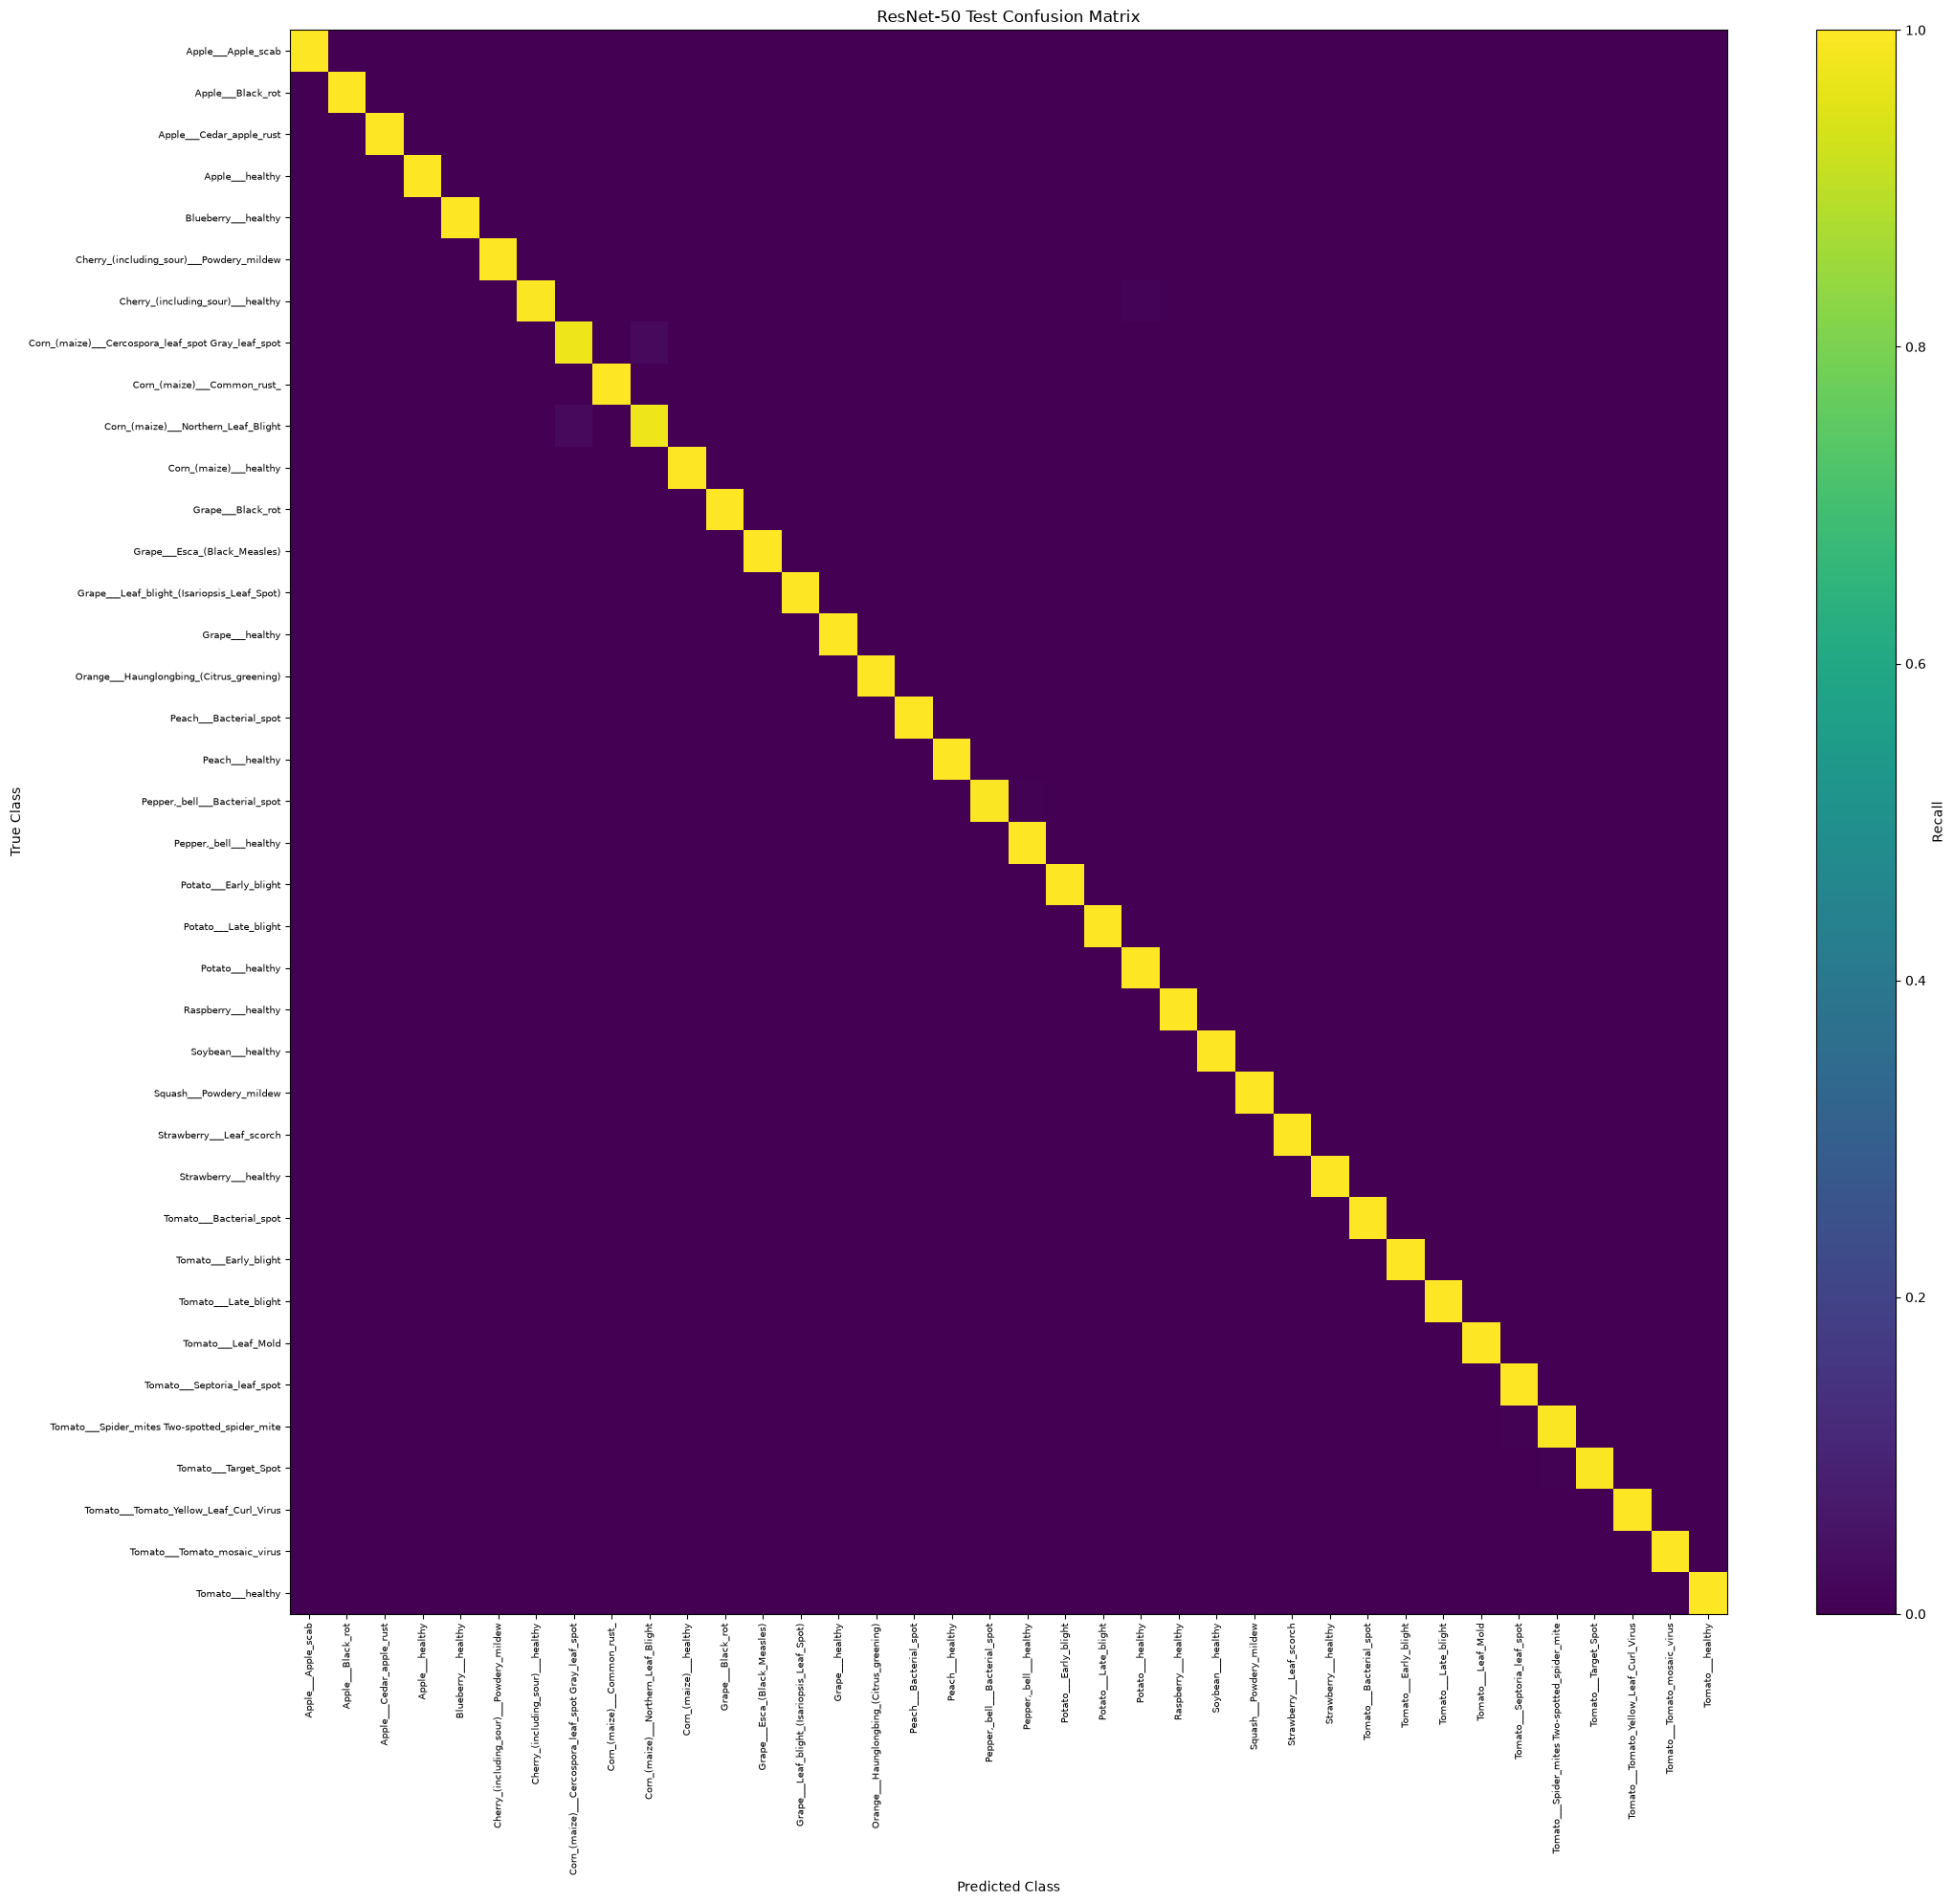

✓ Confusion matrix plot saved to:
C:\Users\cscpr\Downloads\random 2\results\resnet50_confusion_matrix.png

WORST-PERFORMING CLASSES
                                                    precision    recall  f1-score  support
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   0.949367  0.974026  0.961538     77.0
Potato___healthy                                     0.958333  1.000000  0.978723     23.0
Corn_(maize)___Northern_Leaf_Blight                  0.986207  0.972789  0.979452    147.0
Tomato___Spider_mites Two-spotted_spider_mite        0.996032  0.996032  0.996032    252.0
Cherry_(including_sour)___healthy                    1.000000  0.992188  0.996078    128.0
Tomato___Septoria_leaf_spot                          0.996226  0.996226  0.996226    265.0
Pepper,_bell___Bacterial_spot                        1.000000  0.993289  0.996633    149.0
Tomato___Early_blight                                0.993377  1.000000  0.996678    150.0
Tomato___Target_Spot                             

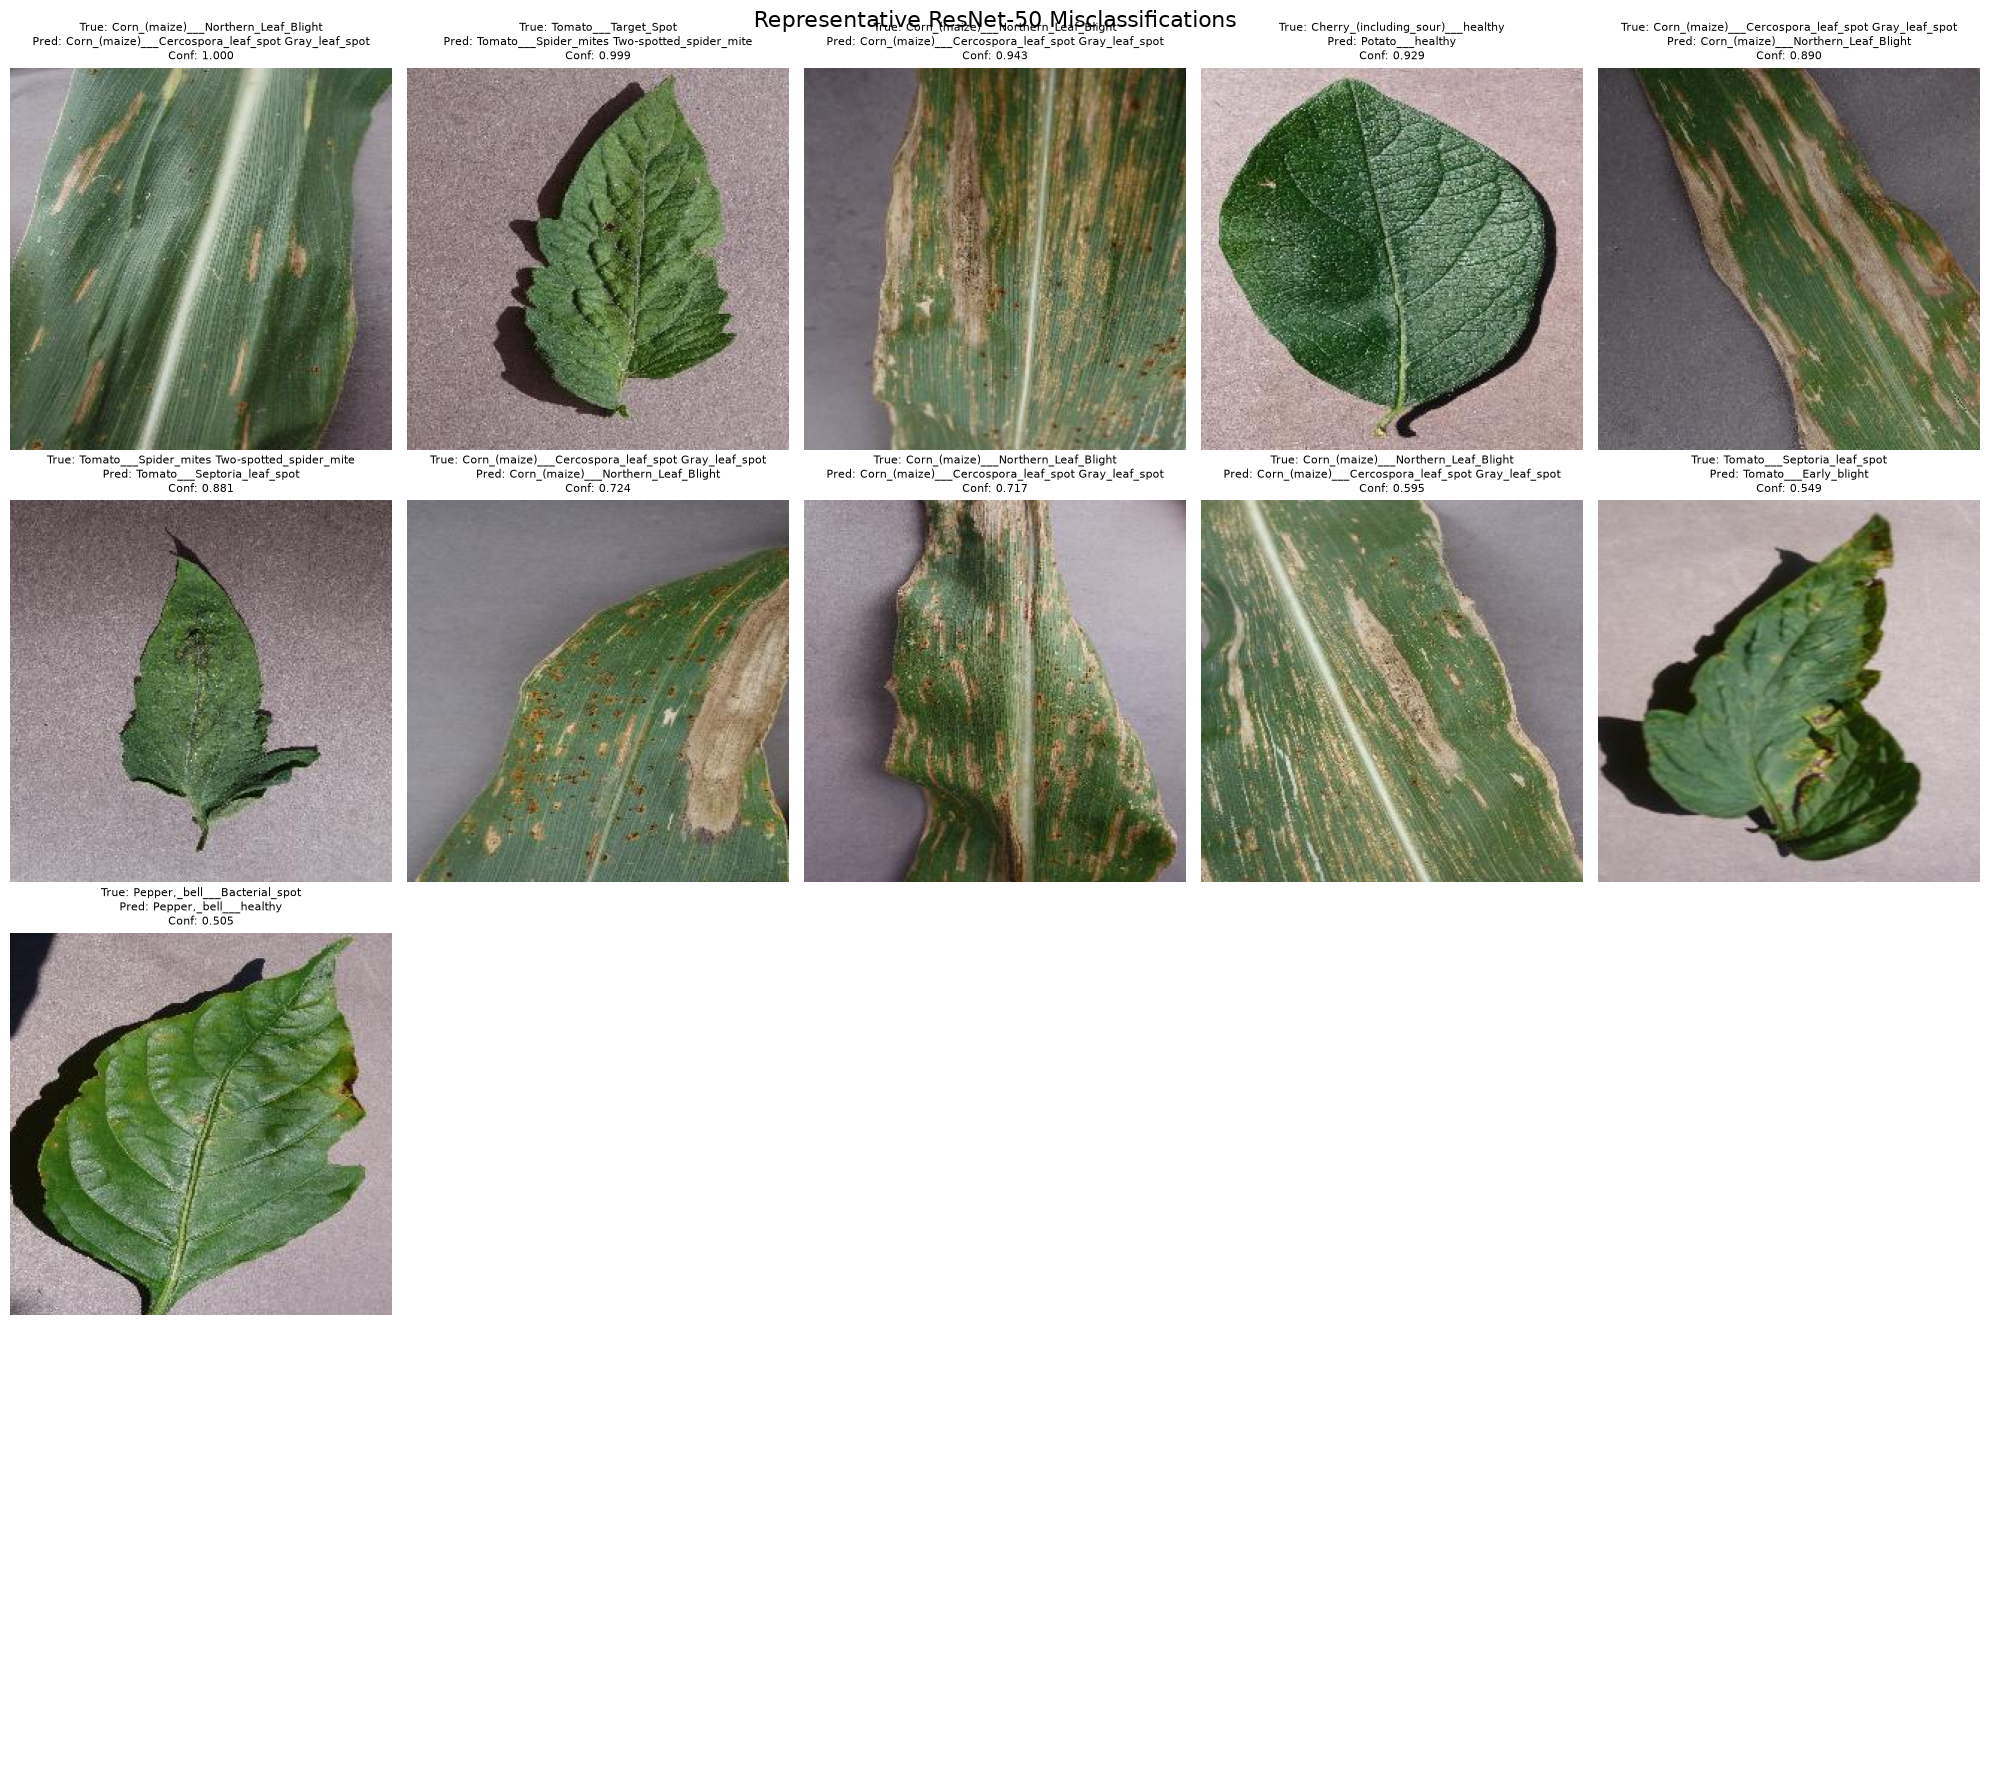

✓ Misclassification figure saved to:
C:\Users\cscpr\Downloads\random 2\results\resnet50_representative_misclassifications.png

LOWEST-RECALL CLASSES
                                                    precision    recall  f1-score  support
Corn_(maize)___Northern_Leaf_Blight                  0.986207  0.972789  0.979452    147.0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   0.949367  0.974026  0.961538     77.0
Cherry_(including_sour)___healthy                    1.000000  0.992188  0.996078    128.0
Pepper,_bell___Bacterial_spot                        1.000000  0.993289  0.996633    149.0
Tomato___Target_Spot                                 1.000000  0.995238  0.997613    210.0
Tomato___Spider_mites Two-spotted_spider_mite        0.996032  0.996032  0.996032    252.0
Tomato___Septoria_leaf_spot                          0.996226  0.996226  0.996226    265.0
Potato___healthy                                     0.958333  1.000000  0.978723     23.0
Tomato___Early_blight           

In [19]:
# ==============================================================
# RESNET-50 — TEST ERROR ANALYSIS
# Confusion Matrix + Per-Class Metrics + Misclassified Samples
# ==============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    f1_score
)

# ==============================================================
# CONFIGURATION
# ==============================================================

SEED = 42

DATASET_ROOT = r"C:\Users\cscpr\Downloads\random 2\plantvillage dataset\color"

SPLIT_FILE = (
    r"C:\Users\cscpr\Downloads\random 2"
    r"\plantvillage_color_stratified_split.csv"
)

CHECKPOINT_PATH = (
    r"C:\Users\cscpr\Downloads\random 2"
    r"\models\resnet50_baseline_best.pth"
)

RESULTS_DIR = r"C:\Users\cscpr\Downloads\random 2\results"

os.makedirs(RESULTS_DIR, exist_ok=True)

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

print("=" * 70)
print("RESNET-50 — TEST ERROR ANALYSIS")
print("=" * 70)

print(f"Device       : {DEVICE}")
print(f"Checkpoint   : {CHECKPOINT_PATH}")
print(f"Split file   : {SPLIT_FILE}")
print()


# ==============================================================
# REPRODUCIBILITY
# ==============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ==============================================================
# LOAD SPLIT
# ==============================================================

df = pd.read_csv(SPLIT_FILE)

df["split"] = df["split"].astype(str)

test_df = df[df["split"].str.lower() == "test"].copy()

print(f"Test images : {len(test_df):,}")


# ==============================================================
# CLASS MAPPING
# ==============================================================

class_names = sorted(
    test_df["class_name"].unique().tolist()
)

class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

idx_to_class = {
    idx: name
    for name, idx in class_to_idx.items()
}

NUM_CLASSES = len(class_names)

print(f"Classes     : {NUM_CLASSES}")

print()
print("Class mapping:")

for idx in range(NUM_CLASSES):
    print(f"{idx:2d} -> {idx_to_class[idx]}")


# ==============================================================
# RESOLVE IMAGE PATHS
# ==============================================================

def resolve_image_path(path_value):

    path_value = str(path_value)

    # Already absolute
    if os.path.isabs(path_value):
        if os.path.exists(path_value):
            return path_value

    # Normalize separators
    normalized = path_value.replace("/", os.sep)

    # If path already contains the dataset root
    candidate = normalized

    if os.path.exists(candidate):
        return candidate

    # Try extracting relative portion after color
    marker = os.path.join(
        "plantvillage dataset",
        "color"
    )

    marker_alt = "plantvillage dataset\\color"

    if marker_alt in normalized:
        relative_part = normalized.split(
            marker_alt,
            1
        )[1].lstrip("\\/")

        candidate = os.path.join(
            DATASET_ROOT,
            relative_part
        )

        if os.path.exists(candidate):
            return candidate

    # If only class/file path is stored
    parts = normalized.split(os.sep)

    if len(parts) >= 2:
        class_name_candidate = parts[-2]
        filename = parts[-1]

        candidate = os.path.join(
            DATASET_ROOT,
            class_name_candidate,
            filename
        )

        if os.path.exists(candidate):
            return candidate

    return None


test_df["resolved_path"] = test_df["path"].apply(
    resolve_image_path
)

missing = test_df[
    test_df["resolved_path"].isna()
]

print()

if len(missing) > 0:

    print(
        f"ERROR: {len(missing)} test images could not be resolved."
    )

    print(missing["path"].head(20).to_string())

    raise FileNotFoundError(
        "Some test image paths could not be resolved."
    )

else:

    print("✓ All test image paths resolved.")


# ==============================================================
# DATASET
# ==============================================================

test_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class PlantVillageDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["resolved_path"]

        image = Image.open(
            image_path
        ).convert("RGB")

        label = class_to_idx[
            row["class_name"]
        ]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


test_dataset = PlantVillageDataset(
    test_df,
    transform=test_transform
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)


# ==============================================================
# LOAD RESNET-50
# ==============================================================

model = models.resnet50(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:

        state_dict = checkpoint[
            "model_state_dict"
        ]

    elif "state_dict" in checkpoint:

        state_dict = checkpoint[
            "state_dict"
        ]

    else:

        state_dict = checkpoint

else:

    state_dict = checkpoint


# Remove possible "module." prefix
clean_state_dict = {}

for key, value in state_dict.items():

    if key.startswith("module."):

        clean_state_dict[
            key[len("module."):]
        ] = value

    else:

        clean_state_dict[key] = value


model.load_state_dict(
    clean_state_dict,
    strict=True
)

model = model.to(DEVICE)
model.eval()

print()
print("✓ ResNet-50 checkpoint loaded.")


if isinstance(checkpoint, dict):

    if "epoch" in checkpoint:
        print(
            f"Checkpoint epoch : {checkpoint['epoch']}"
        )

    if "val_macro_f1" in checkpoint:
        print(
            f"Validation Macro-F1 : "
            f"{checkpoint['val_macro_f1']:.6f}"
        )


# ==============================================================
# TEST INFERENCE
# ==============================================================

all_labels = []
all_predictions = []
all_probabilities = []

print()
print("=" * 70)
print("RUNNING TEST INFERENCE")
print("=" * 70)

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(
        test_loader,
        start=1
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        if USE_AMP:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)

        else:

            outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        if (
            batch_idx == 1
            or batch_idx % 50 == 0
            or batch_idx == len(test_loader)
        ):

            print(
                f"Processed "
                f"{batch_idx}/{len(test_loader)} batches"
            )


y_true = np.asarray(
    all_labels
)

y_pred = np.asarray(
    all_predictions
)

probabilities = np.asarray(
    all_probabilities
)


# ==============================================================
# OVERALL METRICS
# ==============================================================

accuracy = (
    y_true == y_pred
).mean()

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print()
print("=" * 70)
print("OVERALL TEST PERFORMANCE")
print("=" * 70)

print(f"Test images       : {len(y_true):,}")
print(f"Accuracy          : {accuracy * 100:.4f}%")
print(f"Balanced Accuracy : {balanced_acc * 100:.4f}%")
print(f"Macro-F1          : {macro_f1 * 100:.4f}%")
print(f"Weighted-F1       : {weighted_f1 * 100:.4f}%")


# ==============================================================
# CONFUSION MATRIX
# ==============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

cm_normalized = cm.astype(float) / np.maximum(
    cm.sum(axis=1, keepdims=True),
    1
)


# ==============================================================
# SAVE RAW CONFUSION MATRIX
# ==============================================================

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_path = os.path.join(
    RESULTS_DIR,
    "resnet50_confusion_matrix.csv"
)

cm_df.to_csv(
    cm_path
)

print()
print(f"✓ Confusion matrix saved to:")
print(cm_path)


# ==============================================================
# PLOT CONFUSION MATRIX
# ==============================================================

plt.figure(
    figsize=(22, 20)
)

plt.imshow(
    cm_normalized,
    interpolation="nearest",
    aspect="auto"
)

plt.title(
    "ResNet-50 Test Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(NUM_CLASSES),
    class_names,
    fontsize=7
)

plt.colorbar(
    label="Recall"
)

plt.tight_layout()

confusion_plot_path = os.path.join(
    RESULTS_DIR,
    "resnet50_confusion_matrix.png"
)

plt.savefig(
    confusion_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"✓ Confusion matrix plot saved to:"
)
print(confusion_plot_path)


# ==============================================================
# CLASSIFICATION REPORT
# ==============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).T

class_report_df = report_df.loc[
    class_names,
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
].copy()

class_report_df = class_report_df.sort_values(
    "f1-score"
)

print()
print("=" * 70)
print("WORST-PERFORMING CLASSES")
print("=" * 70)

print(
    class_report_df.head(10).to_string()
)


# ==============================================================
# SAVE CLASSIFICATION REPORT
# ==============================================================

class_report_path = os.path.join(
    RESULTS_DIR,
    "resnet50_per_class_error_analysis.csv"
)

class_report_df.to_csv(
    class_report_path
)

print()
print(
    f"✓ Per-class report saved to:"
)
print(class_report_path)


# ==============================================================
# FIND MOST COMMON CONFUSIONS
# ==============================================================
# Ignore correct predictions along the diagonal.

confusion_pairs = []

for true_idx in range(NUM_CLASSES):

    for pred_idx in range(NUM_CLASSES):

        if true_idx == pred_idx:
            continue

        count = cm[
            true_idx,
            pred_idx
        ]

        if count > 0:

            confusion_pairs.append({

                "true_class":
                    idx_to_class[true_idx],

                "predicted_class":
                    idx_to_class[pred_idx],

                "count":
                    int(count),

                "true_class_total":
                    int(cm[true_idx].sum()),

                "error_rate_within_true_class":
                    float(
                        count /
                        max(cm[true_idx].sum(), 1)
                    )

            })


confusion_pairs_df = pd.DataFrame(
    confusion_pairs
)

if len(confusion_pairs_df) > 0:

    confusion_pairs_df = (
        confusion_pairs_df
        .sort_values(
            ["count", "error_rate_within_true_class"],
            ascending=False
        )
        .reset_index(drop=True)
    )

print()
print("=" * 70)
print("TOP CLASS-TO-CLASS CONFUSIONS")
print("=" * 70)

if len(confusion_pairs_df) > 0:

    print(
        confusion_pairs_df.head(20).to_string(
            index=False
        )
    )

else:

    print("No misclassifications found.")


# ==============================================================
# SAVE CONFUSION PAIRS
# ==============================================================

confusion_pairs_path = os.path.join(
    RESULTS_DIR,
    "resnet50_top_confusions.csv"
)

confusion_pairs_df.to_csv(
    confusion_pairs_path,
    index=False
)

print()
print(
    f"✓ Confusion-pair report saved to:"
)
print(confusion_pairs_path)


# ==============================================================
# MISCLASSIFIED IMAGE ANALYSIS
# ==============================================================

misclassified_mask = (
    y_true != y_pred
)

misclassified_indices = np.where(
    misclassified_mask
)[0]

print()
print("=" * 70)
print("MISCLASSIFICATION SUMMARY")
print("=" * 70)

print(
    f"Correct predictions     : "
    f"{np.sum(~misclassified_mask):,}"
)

print(
    f"Incorrect predictions   : "
    f"{np.sum(misclassified_mask):,}"
)

print(
    f"Error rate              : "
    f"{np.mean(misclassified_mask) * 100:.4f}%"
)


# ==============================================================
# BUILD MISCLASSIFICATION TABLE
# ==============================================================

misclassified_rows = []

for dataset_index in misclassified_indices:

    true_idx = int(
        y_true[dataset_index]
    )

    pred_idx = int(
        y_pred[dataset_index]
    )

    confidence = float(
        probabilities[
            dataset_index,
            pred_idx
        ]
    )

    true_probability = float(
        probabilities[
            dataset_index,
            true_idx
        ]
    )

    misclassified_rows.append({

        "dataset_index":
            int(dataset_index),

        "image_path":
            test_df.iloc[
                dataset_index
            ]["resolved_path"],

        "true_class":
            idx_to_class[true_idx],

        "predicted_class":
            idx_to_class[pred_idx],

        "prediction_confidence":
            confidence,

        "true_class_probability":
            true_probability

    })


misclassified_df = pd.DataFrame(
    misclassified_rows
)

if len(misclassified_df) > 0:

    misclassified_df = (
        misclassified_df
        .sort_values(
            "prediction_confidence",
            ascending=False
        )
        .reset_index(drop=True)
    )


# ==============================================================
# SAVE MISCLASSIFIED IMAGES TABLE
# ==============================================================

misclassified_path = os.path.join(
    RESULTS_DIR,
    "resnet50_misclassified_images.csv"
)

misclassified_df.to_csv(
    misclassified_path,
    index=False
)

print()
print(
    f"✓ Misclassified-image table saved to:"
)
print(misclassified_path)


# ==============================================================
# DISPLAY REPRESENTATIVE MISCLASSIFICATIONS
# ==============================================================

NUM_DISPLAY = min(
    20,
    len(misclassified_df)
)

if NUM_DISPLAY > 0:

    print()
    print("=" * 70)
    print(
        f"DISPLAYING {NUM_DISPLAY} REPRESENTATIVE MISCLASSIFICATIONS"
    )
    print("=" * 70)

    # Select a mixture of high-confidence
    # and lower-confidence errors.
    if len(misclassified_df) > NUM_DISPLAY:

        high_count = NUM_DISPLAY // 2

        low_count = (
            NUM_DISPLAY - high_count
        )

        high_errors = (
            misclassified_df.head(
                high_count
            )
        )

        low_errors = (
            misclassified_df.tail(
                low_count
            )
        )

        display_df = pd.concat(
            [
                high_errors,
                low_errors
            ]
        ).drop_duplicates()

    else:

        display_df = misclassified_df.copy()


    n = len(display_df)

    fig, axes = plt.subplots(
        4,
        5,
        figsize=(20, 18)
    )

    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")


    for ax, (_, row) in zip(
        axes,
        display_df.iterrows()
    ):

        try:

            image = Image.open(
                row["image_path"]
            ).convert("RGB")

            ax.imshow(image)

            ax.set_title(
                "True: "
                + row["true_class"]
                + "\nPred: "
                + row["predicted_class"]
                + "\nConf: "
                + f"{row['prediction_confidence']:.3f}",
                fontsize=8
            )

            ax.axis("off")

        except Exception as e:

            ax.text(
                0.5,
                0.5,
                f"Could not load image\n{e}",
                ha="center",
                va="center"
            )

            ax.axis("off")


    plt.suptitle(
        "Representative ResNet-50 Misclassifications",
        fontsize=16
    )

    plt.tight_layout()

    misclassified_plot_path = os.path.join(
        RESULTS_DIR,
        "resnet50_representative_misclassifications.png"
    )

    plt.savefig(
        misclassified_plot_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"✓ Misclassification figure saved to:"
    )

    print(
        misclassified_plot_path
    )

else:

    print()
    print(
        "✓ No misclassified test images found."
    )


# ==============================================================
# LOWEST RECALL CLASSES
# ==============================================================

lowest_recall = (
    class_report_df
    .sort_values("recall")
    .head(10)
)

print()
print("=" * 70)
print("LOWEST-RECALL CLASSES")
print("=" * 70)

print(
    lowest_recall[
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ].to_string()
)


# ==============================================================
# FINAL SUMMARY
# ==============================================================

print()
print("=" * 70)
print("ERROR ANALYSIS COMPLETE")
print("=" * 70)

print(
    f"Test Accuracy       : {accuracy * 100:.4f}%"
)

print(
    f"Test Macro-F1       : {macro_f1 * 100:.4f}%"
)

print(
    f"Misclassified       : "
    f"{len(misclassified_indices):,}"
)

print(
    f"Misclassification % : "
    f"{len(misclassified_indices) / len(y_true) * 100:.4f}%"
)

if len(confusion_pairs_df) > 0:

    print()
    print("Most common confusion:")

    top = confusion_pairs_df.iloc[0]

    print(
        f"  {top['true_class']}"
        f" -> "
        f"{top['predicted_class']}"
        f" : "
        f"{int(top['count'])} images"
    )

print()
print("Generated files:")

print(
    f"  - {cm_path}"
)

print(
    f"  - {confusion_plot_path}"
)

print(
    f"  - {class_report_path}"
)

print(
    f"  - {confusion_pairs_path}"
)

print(
    f"  - {misclassified_path}"
)

if NUM_DISPLAY > 0:

    print(
        f"  - {misclassified_plot_path}"
    )

print()
print("✓ Error analysis completed.")

RESNET-50 — DETAILED MISCLASSIFICATION ANALYSIS
Misclassified images : 11

ALL MISCLASSIFIED TEST IMAGES
                                        true_class                                    predicted_class  prediction_confidence  true_class_probability                                         top2_class  top2_probability                    top3_class  top3_probability
               Corn_(maize)___Northern_Leaf_Blight Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot               0.999512            3.066063e-04                Corn_(maize)___Northern_Leaf_Blight          0.000307       Tomato___Bacterial_spot      6.556511e-07
                              Tomato___Target_Spot      Tomato___Spider_mites Two-spotted_spider_mite               0.999023            1.192093e-03                               Tomato___Target_Spot          0.001192          Potato___Late_blight      1.323223e-05
               Corn_(maize)___Northern_Leaf_Blight Corn_(maize)___Cercospora_leaf_spot Gray_leaf_

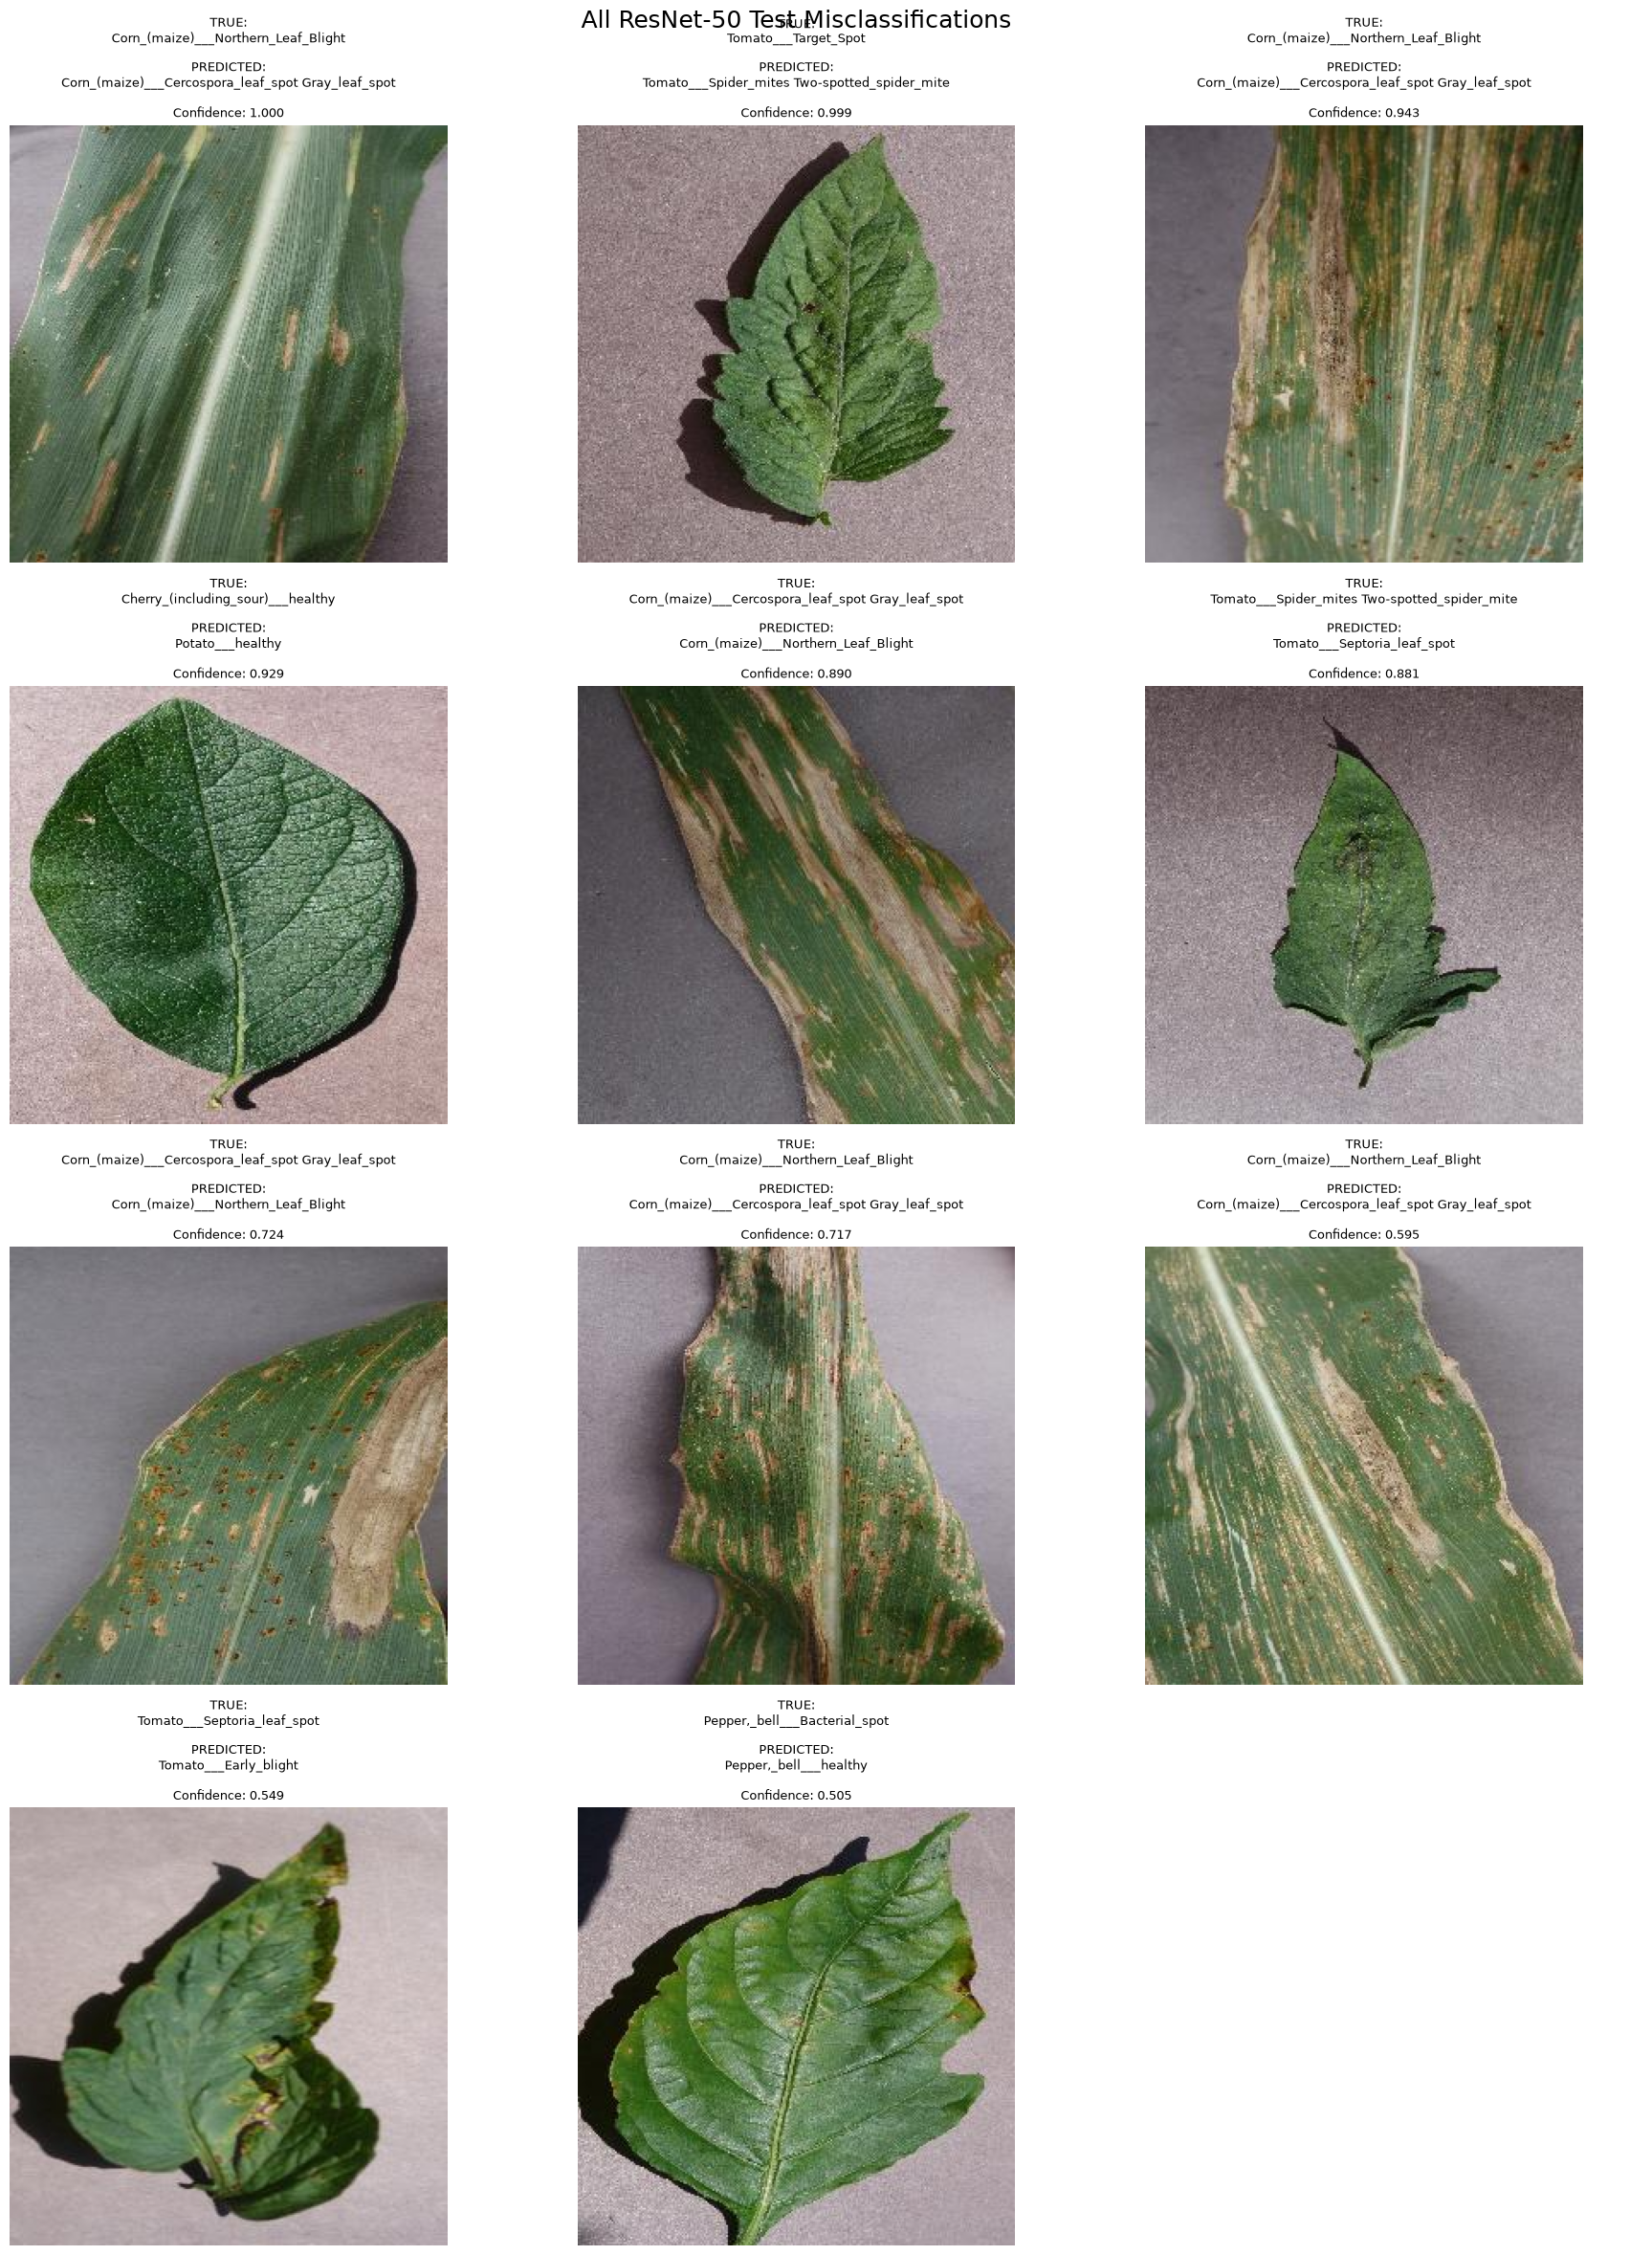


✓ Complete misclassification figure saved to:
C:\Users\cscpr\Downloads\random 2\results\resnet50_all_misclassifications.png

CORN DISEASE CONFUSION ANALYSIS
                                        true_class                                    predicted_class  prediction_confidence  true_class_probability                                         top2_class  top2_probability                  top3_class  top3_probability
               Corn_(maize)___Northern_Leaf_Blight Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot               0.999512                0.000307                Corn_(maize)___Northern_Leaf_Blight          0.000307     Tomato___Bacterial_spot      6.556511e-07
               Corn_(maize)___Northern_Leaf_Blight Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot               0.942871                0.057281                Corn_(maize)___Northern_Leaf_Blight          0.057281 Corn_(maize)___Common_rust_      2.670288e-05
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot

In [20]:
# ==============================================================
# RESNET-50 — DETAILED MISCLASSIFICATION ANALYSIS
# Top-3 Predictions + Confidence + Visual Inspection
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("=" * 70)
print("RESNET-50 — DETAILED MISCLASSIFICATION ANALYSIS")
print("=" * 70)

# --------------------------------------------------------------
# Verify required variables from previous error-analysis cell
# --------------------------------------------------------------

required_variables = [
    "misclassified_df",
    "probabilities",
    "y_true",
    "y_pred",
    "idx_to_class",
    "class_names",
    "RESULTS_DIR"
]

missing_variables = [
    v for v in required_variables
    if v not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Missing variables from previous cell: "
        + ", ".join(missing_variables)
        + "\nPlease run the previous Error Analysis cell first."
    )

print(
    f"Misclassified images : {len(misclassified_df)}"
)


# ==============================================================
# BUILD DETAILED ERROR TABLE
# ==============================================================

detailed_errors = []

for dataset_index in np.where(
    y_true != y_pred
)[0]:

    true_idx = int(
        y_true[dataset_index]
    )

    pred_idx = int(
        y_pred[dataset_index]
    )

    probs = probabilities[
        dataset_index
    ]

    # Top-3 predicted classes
    top3_indices = np.argsort(
        probs
    )[-3:][::-1]

    top3_classes = [
        idx_to_class[int(i)]
        for i in top3_indices
    ]

    top3_probs = [
        float(probs[int(i)])
        for i in top3_indices
    ]

    image_path = test_df.iloc[
        dataset_index
    ]["resolved_path"]

    detailed_errors.append({

        "dataset_index":
            int(dataset_index),

        "image_path":
            image_path,

        "true_class":
            idx_to_class[true_idx],

        "predicted_class":
            idx_to_class[pred_idx],

        "prediction_confidence":
            float(probs[pred_idx]),

        "true_class_probability":
            float(probs[true_idx]),

        "top1_class":
            top3_classes[0],

        "top1_probability":
            top3_probs[0],

        "top2_class":
            top3_classes[1],

        "top2_probability":
            top3_probs[1],

        "top3_class":
            top3_classes[2],

        "top3_probability":
            top3_probs[2]

    })


detailed_errors_df = pd.DataFrame(
    detailed_errors
)


# ==============================================================
# SORT BY PREDICTION CONFIDENCE
# ==============================================================

detailed_errors_df = (
    detailed_errors_df
    .sort_values(
        "prediction_confidence",
        ascending=False
    )
    .reset_index(drop=True)
)


# ==============================================================
# DISPLAY COMPLETE ERROR TABLE
# ==============================================================

print()
print("=" * 70)
print("ALL MISCLASSIFIED TEST IMAGES")
print("=" * 70)

display_columns = [
    "true_class",
    "predicted_class",
    "prediction_confidence",
    "true_class_probability",
    "top2_class",
    "top2_probability",
    "top3_class",
    "top3_probability"
]

print(
    detailed_errors_df[
        display_columns
    ].to_string(index=False)
)


# ==============================================================
# SAVE DETAILED ERROR TABLE
# ==============================================================

detailed_errors_path = os.path.join(
    RESULTS_DIR,
    "resnet50_detailed_misclassification_analysis.csv"
)

detailed_errors_df.to_csv(
    detailed_errors_path,
    index=False
)

print()
print(
    "✓ Detailed error table saved to:"
)

print(
    detailed_errors_path
)


# ==============================================================
# ERROR TYPE ANALYSIS
# ==============================================================

print()
print("=" * 70)
print("ERROR TYPE ANALYSIS")
print("=" * 70)

# Whether the true class was in top-3
top3_hits = []

for _, row in detailed_errors_df.iterrows():

    true_class = row["true_class"]

    top3_hits.append(
        true_class in [
            row["top1_class"],
            row["top2_class"],
            row["top3_class"]
        ]
    )

top3_rate = (
    np.mean(top3_hits) * 100
)

print(
    f"True class present in Top-3 : "
    f"{top3_rate:.2f}% of errors"
)


# ==============================================================
# CONFIDENCE OF WRONG PREDICTIONS
# ==============================================================

print()

print(
    f"Mean wrong-prediction confidence : "
    f"{detailed_errors_df['prediction_confidence'].mean():.4f}"
)

print(
    f"Minimum wrong-prediction confidence : "
    f"{detailed_errors_df['prediction_confidence'].min():.4f}"
)

print(
    f"Maximum wrong-prediction confidence : "
    f"{detailed_errors_df['prediction_confidence'].max():.4f}"
)


# ==============================================================
# VISUALIZE ALL 11 ERRORS
# ==============================================================

num_errors = len(
    detailed_errors_df
)

if num_errors > 0:

    columns = 3

    rows = int(
        np.ceil(
            num_errors / columns
        )
    )

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(18, 6 * rows)
    )

    axes = np.asarray(
        axes
    ).reshape(-1)

    for ax in axes:
        ax.axis("off")


    for ax, (_, row) in zip(
        axes,
        detailed_errors_df.iterrows()
    ):

        try:

            image = Image.open(
                row["image_path"]
            ).convert("RGB")

            ax.imshow(image)

            title = (
                "TRUE:\n"
                + row["true_class"]
                + "\n\nPREDICTED:\n"
                + row["predicted_class"]
                + f"\n\nConfidence: "
                + f"{row['prediction_confidence']:.3f}"
            )

            ax.set_title(
                title,
                fontsize=9
            )

            ax.axis("off")

        except Exception as e:

            ax.text(
                0.5,
                0.5,
                "Image loading failed\n"
                + str(e),
                ha="center",
                va="center"
            )

            ax.axis("off")


    plt.suptitle(
        "All ResNet-50 Test Misclassifications",
        fontsize=18
    )

    plt.tight_layout()

    detailed_plot_path = os.path.join(
        RESULTS_DIR,
        "resnet50_all_misclassifications.png"
    )

    plt.savefig(
        detailed_plot_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print()
    print(
        "✓ Complete misclassification figure saved to:"
    )

    print(
        detailed_plot_path
    )


# ==============================================================
# FOCUS ON CORN CONFUSIONS
# ==============================================================

corn_mask = (
    detailed_errors_df["true_class"].str.startswith(
        "Corn_(maize)"
    )
)

corn_errors = detailed_errors_df[
    corn_mask
].copy()

print()
print("=" * 70)
print("CORN DISEASE CONFUSION ANALYSIS")
print("=" * 70)

if len(corn_errors) > 0:

    print(
        corn_errors[
            display_columns
        ].to_string(index=False)
    )

else:

    print(
        "No Corn-specific errors found."
    )


# ==============================================================
# SAVE CORN ERROR TABLE
# ==============================================================

corn_error_path = os.path.join(
    RESULTS_DIR,
    "resnet50_corn_misclassification_analysis.csv"
)

corn_errors.to_csv(
    corn_error_path,
    index=False
)

print()
print(
    "✓ Corn error analysis saved to:"
)

print(
    corn_error_path
)


# ==============================================================
# FINAL INTERPRETATION
# ==============================================================

print()
print("=" * 70)
print("ERROR ANALYSIS INTERPRETATION")
print("=" * 70)

print(
    "The clean test set contains only "
    f"{num_errors} misclassified images."
)

print()

if len(corn_errors) >= 2:

    print(
        "Primary error pattern:"
    )

    print(
        "Corn disease discrimination, particularly "
        "Northern Leaf Blight vs "
        "Cercospora/Gray Leaf Spot."
    )

print()

print(
    "The next modeling decision should be based on "
    "these actual error images rather than clean-test "
    "accuracy alone."
)

print()
print(
    "✓ Detailed misclassification analysis complete."
)

In [21]:
# ================================================================
# RESNET-50 ROBUST TRAINING
# ================================================================
# Goal:
# Improve robustness against the corruption types identified in
# the baseline evaluation, especially Gaussian noise and blur.
#
# IMPORTANT:
# - Training data: augmentation enabled
# - Validation data: CLEAN
# - Test data: NEVER used during training
# - Best model selected using validation Macro-F1
# ================================================================

import os
import random
import time
import copy
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

# ================================================================
# CONFIGURATION
# ================================================================

SEED = 42

ROOT_DIR = r"C:\Users\cscpr\Downloads\random 2"

SPLIT_FILE = os.path.join(
    ROOT_DIR,
    "plantvillage_color_stratified_split.csv"
)

MODEL_DIR = os.path.join(
    ROOT_DIR,
    "models"
)

RESULTS_DIR = os.path.join(
    ROOT_DIR,
    "results"
)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

ROBUST_CHECKPOINT = os.path.join(
    MODEL_DIR,
    "resnet50_robust_best.pth"
)

HISTORY_FILE = os.path.join(
    RESULTS_DIR,
    "resnet50_robust_training_history.csv"
)

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

NUM_EPOCHS = 15

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

PATIENCE = 4

NUM_CLASSES = 38

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

# ================================================================
# REPRODUCIBILITY
# ================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

print("=" * 70)
print("RESNET-50 ROBUST TRAINING")
print("=" * 70)

print(f"Device          : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(
        f"GPU memory      : "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )

print(f"AMP enabled     : {USE_AMP}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Epochs          : {NUM_EPOCHS}")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Weight decay    : {WEIGHT_DECAY}")
print(f"Patience        : {PATIENCE}")

print()
print(f"Split file      : {SPLIT_FILE}")
print(f"Output model    : {ROBUST_CHECKPOINT}")

# ================================================================
# LOAD SPLIT
# ================================================================

print()
print("=" * 70)
print("LOADING DATA SPLIT")
print("=" * 70)

df = pd.read_csv(SPLIT_FILE)

required_columns = {"path", "class_name", "split"}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

df["split"] = df["split"].astype(str)
df["class_name"] = df["class_name"].astype(str)

# ================================================================
# CLASS MAPPING
# ================================================================

class_names = sorted(
    df["class_name"].unique().tolist()
)

if len(class_names) != NUM_CLASSES:
    raise ValueError(
        f"Expected {NUM_CLASSES} classes, "
        f"found {len(class_names)}"
    )

class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

idx_to_class = {
    idx: name
    for name, idx in class_to_idx.items()
}

df["label"] = df["class_name"].map(class_to_idx)

print()
print("Class mapping:")

for idx in range(NUM_CLASSES):
    print(
        f"{idx:2d} -> {idx_to_class[idx]}"
    )

# ================================================================
# VERIFY PATHS
# ================================================================

print()
print("=" * 70)
print("VERIFYING IMAGE PATHS")
print("=" * 70)

missing_paths = []

for path in df["path"].head(100).tolist():

    if not os.path.exists(path):
        missing_paths.append(path)

if missing_paths:
    raise FileNotFoundError(
        f"Missing image paths detected. "
        f"Examples: {missing_paths[:5]}"
    )

print("✓ Sample image paths verified.")

# ================================================================
# DATASET
# ================================================================

class PlantVillageDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["path"]
        label = int(row["label"])

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# ================================================================
# ROBUST TRAINING TRANSFORMS
# ================================================================
#
# The corruption evaluation showed:
#
# Gaussian Noise -> major degradation
# Gaussian Blur  -> major degradation
#
# Therefore the training pipeline explicitly exposes the model
# to these transformations.
#
# Additional mild transformations improve generalization without
# destroying the plant-disease structure.
# ================================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


class AddGaussianNoise:

    def __init__(
        self,
        mean=0.0,
        std=0.04,
        p=0.35
    ):

        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, tensor):

        if random.random() > self.p:
            return tensor

        noise = torch.randn_like(
            tensor
        ) * self.std + self.mean

        tensor = tensor + noise

        return torch.clamp(
            tensor,
            0.0,
            1.0
        )


class RandomJPEG:

    """
    PIL JPEG round-trip augmentation.

    This simulates image-compression artifacts
    without requiring an additional library.
    """

    def __init__(
        self,
        quality_range=(45, 85),
        p=0.20
    ):

        self.quality_range = quality_range
        self.p = p

    def __call__(self, image):

        if random.random() > self.p:
            return image

        import io

        quality = random.randint(
            self.quality_range[0],
            self.quality_range[1]
        )

        buffer = io.BytesIO()

        image.save(
            buffer,
            format="JPEG",
            quality=quality
        )

        buffer.seek(0)

        compressed = Image.open(
            buffer
        ).convert("RGB")

        return compressed


class RandomOcclusion:

    def __init__(
        self,
        p=0.20,
        max_fraction=0.15
    ):

        self.p = p
        self.max_fraction = max_fraction

    def __call__(self, image):

        if random.random() > self.p:
            return image

        image = image.copy()

        width, height = image.size

        max_w = max(
            1,
            int(width * self.max_fraction)
        )

        max_h = max(
            1,
            int(height * self.max_fraction)
        )

        occ_w = random.randint(
            1,
            max_w
        )

        occ_h = random.randint(
            1,
            max_h
        )

        x = random.randint(
            0,
            max(0, width - occ_w)
        )

        y = random.randint(
            0,
            max(0, height - occ_h)
        )

        # Use a local average-like neutral value.
        fill_value = (
            random.randint(0, 255),
            random.randint(0, 255),
            random.randint(0, 255)
        )

        from PIL import ImageDraw

        draw = ImageDraw.Draw(image)

        draw.rectangle(
            [
                x,
                y,
                x + occ_w,
                y + occ_h
            ],
            fill=fill_value
        )

        return image


train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.15
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    RandomJPEG(
        quality_range=(45, 85),
        p=0.20
    ),

    transforms.RandomApply(
        [
            transforms.GaussianBlur(
                kernel_size=5,
                sigma=(0.1, 1.5)
            )
        ],
        p=0.25
    ),

    RandomOcclusion(
        p=0.20,
        max_fraction=0.15
    ),

    transforms.ToTensor(),

    AddGaussianNoise(
        mean=0.0,
        std=0.04,
        p=0.35
    ),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ================================================================
# CLEAN VALIDATION TRANSFORM
# ================================================================
#
# IMPORTANT:
# Validation remains clean so that model selection is comparable
# to the baseline experiment.
# ================================================================

val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# ================================================================
# CREATE DATASETS
# ================================================================

train_df = df[
    df["split"] == "train"
].copy()

val_df = df[
    df["split"] == "validation"
].copy()

test_df = df[
    df["split"] == "test"
].copy()

print()
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(
    f"Train       : {len(train_df):,}"
)

print(
    f"Validation  : {len(val_df):,}"
)

print(
    f"Test        : {len(test_df):,}"
)

if len(train_df) != 38012:
    print(
        "WARNING: unexpected training count."
    )

if len(val_df) != 8146:
    print(
        "WARNING: unexpected validation count."
    )

if len(test_df) != 8147:
    print(
        "WARNING: unexpected test count."
    )

# ================================================================
# DATA LOADERS
# ================================================================

train_dataset = PlantVillageDataset(
    train_df,
    transform=train_transform
)

val_dataset = PlantVillageDataset(
    val_df,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

print()
print("✓ DataLoaders created.")

# ================================================================
# MODEL
# ================================================================

print()
print("=" * 70)
print("CREATING RESNET-50")
print("=" * 70)

weights = models.ResNet50_Weights.DEFAULT

model = models.resnet50(
    weights=weights
)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print(model.fc)

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print()
print(
    f"Total parameters     : {total_parameters:,}"
)

print(
    f"Trainable parameters : {trainable_parameters:,}"
)

# ================================================================
# LOSS
# ================================================================

criterion = nn.CrossEntropyLoss()

# ================================================================
# OPTIMIZER
# ================================================================

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ================================================================
# LR SCHEDULER
# ================================================================
#
# Reduce LR when validation Macro-F1 stops improving.
# ================================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# ================================================================
# AMP
# ================================================================

scaler = torch.cuda.amp.GradScaler(
    enabled=USE_AMP
)

# ================================================================
# TRAINING FUNCTIONS
# ================================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0

    all_targets = []
    all_predictions = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type=device.type,
            enabled=USE_AMP
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_targets.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        epoch_loss,
        accuracy,
        macro_f1
    )


@torch.no_grad()
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_targets = []
    all_predictions = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type=device.type,
            enabled=USE_AMP
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_targets.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        epoch_loss,
        accuracy,
        balanced_accuracy,
        macro_f1
    )

# ================================================================
# TRAINING LOOP
# ================================================================

print()
print("=" * 70)
print("ROBUST RESNET-50 TRAINING")
print("=" * 70)

history = []

best_macro_f1 = -np.inf
best_epoch = 0
best_state = None

epochs_without_improvement = 0

training_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start = time.time()

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        DEVICE
    )

    val_loss, val_acc, val_bal_acc, val_f1 = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(
        val_f1
    )

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_time = (
        time.time() -
        epoch_start
    )

    is_best = (
        val_f1 > best_macro_f1
    )

    if is_best:

        best_macro_f1 = val_f1
        best_epoch = epoch

        best_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    history.append({

        "epoch": epoch,

        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_f1,

        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_balanced_accuracy": val_bal_acc,
        "val_macro_f1": val_f1,

        "learning_rate": current_lr,

        "epoch_time_seconds": epoch_time

    })

    marker = "✓ BEST" if is_best else ""

    print()
    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} {marker}"
    )

    print(
        f"  Train Loss       : {train_loss:.4f}"
    )

    print(
        f"  Train Accuracy   : {train_acc:.4f}"
    )

    print(
        f"  Train Macro-F1   : {train_f1:.4f}"
    )

    print(
        f"  Val Loss         : {val_loss:.4f}"
    )

    print(
        f"  Val Accuracy     : {val_acc:.4f}"
    )

    print(
        f"  Val Balanced Acc : {val_bal_acc:.4f}"
    )

    print(
        f"  Val Macro-F1     : {val_f1:.4f}"
    )

    print(
        f"  Learning Rate    : {current_lr:.7f}"
    )

    print(
        f"  Time             : {epoch_time:.1f}s"
    )

    if epochs_without_improvement >= PATIENCE:

        print()
        print(
            f"Early stopping triggered "
            f"after {epoch} epochs."
        )

        break

# ================================================================
# RESTORE BEST MODEL
# ================================================================

if best_state is None:
    raise RuntimeError(
        "No best model state was recorded."
    )

model.load_state_dict(
    best_state
)

# ================================================================
# SAVE CHECKPOINT
# ================================================================

checkpoint = {

    "epoch": best_epoch,

    "model_state_dict":
        model.state_dict(),

    "optimizer_state_dict":
        optimizer.state_dict(),

    "best_val_macro_f1":
        best_macro_f1,

    "class_names":
        class_names,

    "class_to_idx":
        class_to_idx,

    "image_size":
        IMAGE_SIZE,

    "seed":
        SEED,

    "model_name":
        "resnet50_robust",

    "training_type":
        "corruption_augmented",

    "hyperparameters": {

        "batch_size":
            BATCH_SIZE,

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "num_epochs":
            NUM_EPOCHS,

        "patience":
            PATIENCE

    }

}

torch.save(
    checkpoint,
    ROBUST_CHECKPOINT
)

# ================================================================
# SAVE HISTORY
# ================================================================

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    HISTORY_FILE,
    index=False
)

training_time = (
    time.time() -
    training_start
)

# ================================================================
# FINAL SUMMARY
# ================================================================

print()
print("=" * 70)
print("ROBUST TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best epoch       : {best_epoch}"
)

print(
    f"Best Val Macro-F1: {best_macro_f1:.4f}"
)

print(
    f"Training time    : "
    f"{training_time / 60:.2f} minutes"
)

print()
print(
    "Best model saved to:"
)

print(
    ROBUST_CHECKPOINT
)

print()
print(
    "Training history saved to:"
)

print(
    HISTORY_FILE
)

print()
print("✓ Robust ResNet-50 training completed.")
print()
print("NEXT STEP:")
print(
    "Run clean TEST evaluation first, then run the "
    "same corrected robustness evaluation used for "
    "the baseline."
)

RESNET-50 ROBUST TRAINING
Device          : cuda
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU
GPU memory      : 6.00 GB
AMP enabled     : True
Batch size      : 32
Epochs          : 15
Learning rate   : 0.0001
Weight decay    : 0.0001
Patience        : 4

Split file      : C:\Users\cscpr\Downloads\random 2\plantvillage_color_stratified_split.csv
Output model    : C:\Users\cscpr\Downloads\random 2\models\resnet50_robust_best.pth

LOADING DATA SPLIT

Class mapping:
 0 -> Apple___Apple_scab
 1 -> Apple___Black_rot
 2 -> Apple___Cedar_apple_rust
 3 -> Apple___healthy
 4 -> Blueberry___healthy
 5 -> Cherry_(including_sour)___Powdery_mildew
 6 -> Cherry_(including_sour)___healthy
 7 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 8 -> Corn_(maize)___Common_rust_
 9 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Ha

C:\Users\cscpr\AppData\Local\Temp\ipykernel_16084\338633161.py:670: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(



Epoch 01/15 ✓ BEST
  Train Loss       : 0.3733
  Train Accuracy   : 0.9018
  Train Macro-F1   : 0.8816
  Val Loss         : 0.0324
  Val Accuracy     : 0.9896
  Val Balanced Acc : 0.9876
  Val Macro-F1     : 0.9865
  Learning Rate    : 0.0001000
  Time             : 814.1s

Epoch 02/15 ✓ BEST
  Train Loss       : 0.0635
  Train Accuracy   : 0.9800
  Train Macro-F1   : 0.9740
  Val Loss         : 0.0232
  Val Accuracy     : 0.9924
  Val Balanced Acc : 0.9879
  Val Macro-F1     : 0.9887
  Learning Rate    : 0.0001000
  Time             : 771.9s

Epoch 03/15 ✓ BEST
  Train Loss       : 0.0453
  Train Accuracy   : 0.9858
  Train Macro-F1   : 0.9814
  Val Loss         : 0.0190
  Val Accuracy     : 0.9942
  Val Balanced Acc : 0.9922
  Val Macro-F1     : 0.9909
  Learning Rate    : 0.0001000
  Time             : 772.0s

Epoch 04/15 ✓ BEST
  Train Loss       : 0.0339
  Train Accuracy   : 0.9891
  Train Macro-F1   : 0.9860
  Val Loss         : 0.0149
  Val Accuracy     : 0.9957
  Val Balanced 

In [22]:
# ================================================================
# RESNET-50 ROBUST MODEL — CLEAN TEST EVALUATION
# ================================================================

import os
import time
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

# ================================================================
# CONFIGURATION
# ================================================================

SEED = 42

SPLIT_FILE = r"C:\Users\cscpr\Downloads\random 2\plantvillage_color_stratified_split.csv"

CHECKPOINT = r"C:\Users\cscpr\Downloads\random 2\models\resnet50_robust_best.pth"

RESULTS_DIR = r"C:\Users\cscpr\Downloads\random 2\results"

REPORT_FILE = os.path.join(
    RESULTS_DIR,
    "resnet50_robust_clean_test_report.txt"
)

os.makedirs(RESULTS_DIR, exist_ok=True)

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_CLASSES = 38

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

USE_AMP = DEVICE.type == "cuda"

# ================================================================
# REPRODUCIBILITY
# ================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ================================================================
# PRINT CONFIGURATION
# ================================================================

print("=" * 70)
print("RESNET-50 ROBUST MODEL — CLEAN TEST EVALUATION")
print("=" * 70)

print(f"Device       : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")

print(f"AMP enabled  : {USE_AMP}")

print(f"Checkpoint   : {CHECKPOINT}")
print(f"Split file   : {SPLIT_FILE}")

# ================================================================
# CLASS MAPPING
# ================================================================

CLASS_NAMES = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy",
    "Blueberry___healthy",
    "Cherry_(including_sour)___Powdery_mildew",
    "Cherry_(including_sour)___healthy",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)___healthy",
    "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)",
    "Grape___healthy",
    "Orange___Haunglongbing_(Citrus_greening)",
    "Peach___Bacterial_spot",
    "Peach___healthy",
    "Pepper,_bell___Bacterial_spot",
    "Pepper,_bell___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Raspberry___healthy",
    "Soybean___healthy",
    "Squash___Powdery_mildew",
    "Strawberry___Leaf_scorch",
    "Strawberry___healthy",
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy"
]

assert len(CLASS_NAMES) == NUM_CLASSES

CLASS_TO_IDX = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

# ================================================================
# LOAD SPLIT
# ================================================================

print("\n" + "=" * 70)
print("LOADING TEST SPLIT")
print("=" * 70)

df = pd.read_csv(SPLIT_FILE)

print(f"Total rows in split : {len(df):,}")
print(f"Columns             : {list(df.columns)}")

# Check required columns
required_columns = {"path", "class_name", "split"}

missing = required_columns - set(df.columns)

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

test_df = df[df["split"] == "test"].copy()

print(f"Test images         : {len(test_df):,}")

# ================================================================
# VERIFY PATHS
# ================================================================

print("\nChecking test image paths...")

missing_paths = [
    p for p in test_df["path"]
    if not os.path.exists(p)
]

if missing_paths:
    print(f"ERROR: {len(missing_paths)} image paths do not exist.")
    print("First missing path:")
    print(missing_paths[0])
    raise FileNotFoundError("Test image paths are missing.")

print("✓ All test image paths resolved.")

# ================================================================
# VERIFY CLASS MAPPING
# ================================================================

unknown_classes = set(test_df["class_name"]) - set(CLASS_NAMES)

if unknown_classes:
    raise ValueError(
        f"Unknown classes found: {unknown_classes}"
    )

test_df["label"] = test_df["class_name"].map(CLASS_TO_IDX)

# ================================================================
# DATASET
# ================================================================

class PlantVillageDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = row["path"]
        label = int(row["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# ================================================================
# TEST TRANSFORM
# ================================================================

test_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        antialias=True
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ================================================================
# CREATE TEST DATASET / DATALOADER
# ================================================================

test_dataset = PlantVillageDataset(
    test_df,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

print(f"✓ Test dataset created.")
print(f"✓ Test batches: {len(test_loader)}")

# ================================================================
# CREATE RESNET-50
# ================================================================

print("\n" + "=" * 70)
print("CREATING RESNET-50")
print("=" * 70)

model = models.resnet50(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

# ================================================================
# LOAD ROBUST CHECKPOINT
# ================================================================

print("\nLoading robust checkpoint...")

checkpoint = torch.load(
    CHECKPOINT,
    map_location=DEVICE
)

# Handle either full checkpoint or state_dict-only checkpoint
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    checkpoint_epoch = checkpoint.get(
        "epoch",
        "unknown"
    )

    checkpoint_val_f1 = checkpoint.get(
        "val_macro_f1",
        checkpoint.get(
            "best_val_macro_f1",
            "unknown"
        )
    )

else:

    model.load_state_dict(checkpoint)

    checkpoint_epoch = "unknown"
    checkpoint_val_f1 = "unknown"


model.eval()

print("✓ Robust ResNet-50 checkpoint loaded.")

print(f"Checkpoint epoch       : {checkpoint_epoch}")
print(f"Checkpoint Val Macro-F1: {checkpoint_val_f1}")

# ================================================================
# LOSS
# ================================================================

criterion = nn.CrossEntropyLoss()

# ================================================================
# TEST INFERENCE
# ================================================================

print("\n" + "=" * 70)
print("RUNNING CLEAN TEST INFERENCE")
print("=" * 70)

all_labels = []
all_predictions = []

total_loss = 0.0
total_samples = 0

start_time = time.time()

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        if USE_AMP:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

        else:

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        batch_size = labels.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        if (
            batch_idx == 0
            or (batch_idx + 1) % 50 == 0
            or (batch_idx + 1) == len(test_loader)
        ):

            print(
                f"Processed "
                f"{batch_idx + 1}/{len(test_loader)} batches"
            )

inference_time = time.time() - start_time

# ================================================================
# METRICS
# ================================================================

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

test_loss = total_loss / total_samples

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

balanced_accuracy = balanced_accuracy_score(
    all_labels,
    all_predictions
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

# ================================================================
# CLASSIFICATION REPORT
# ================================================================

report = classification_report(
    all_labels,
    all_predictions,
    labels=np.arange(NUM_CLASSES),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

# ================================================================
# PRINT RESULTS
# ================================================================

print("\n" + "=" * 70)
print("ROBUST MODEL — CLEAN TEST RESULTS")
print("=" * 70)

print(f"Test images            : {total_samples:,}")
print(f"Test Loss              : {test_loss:.6f}")
print(f"Test Accuracy          : {accuracy * 100:.4f}%")
print(
    f"Test Balanced Accuracy : "
    f"{balanced_accuracy * 100:.4f}%"
)
print(f"Test Macro-F1          : {macro_f1 * 100:.4f}%")
print(f"Test Weighted-F1       : {weighted_f1 * 100:.4f}%")
print(
    f"Inference time         : "
    f"{inference_time:.1f} seconds"
)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(report)

# ================================================================
# COMPARE WITH BASELINE
# ================================================================

BASELINE_ACCURACY = 99.8650
BASELINE_BALANCED = 99.7889
BASELINE_MACRO_F1 = 99.7282
BASELINE_WEIGHTED_F1 = 99.8653

print("\n" + "=" * 70)
print("BASELINE vs ROBUST MODEL")
print("=" * 70)

print(
    f"{'Metric':<25}"
    f"{'Baseline':>15}"
    f"{'Robust':>15}"
    f"{'Change':>15}"
)

print("-" * 70)

print(
    f"{'Accuracy':<25}"
    f"{BASELINE_ACCURACY:>14.4f}%"
    f"{accuracy * 100:>14.4f}%"
    f"{accuracy * 100 - BASELINE_ACCURACY:>+14.4f}"
)

print(
    f"{'Balanced Accuracy':<25}"
    f"{BASELINE_BALANCED:>14.4f}%"
    f"{balanced_accuracy * 100:>14.4f}%"
    f"{balanced_accuracy * 100 - BASELINE_BALANCED:>+14.4f}"
)

print(
    f"{'Macro-F1':<25}"
    f"{BASELINE_MACRO_F1:>14.4f}%"
    f"{macro_f1 * 100:>14.4f}%"
    f"{macro_f1 * 100 - BASELINE_MACRO_F1:>+14.4f}"
)

print(
    f"{'Weighted-F1':<25}"
    f"{BASELINE_WEIGHTED_F1:>14.4f}%"
    f"{weighted_f1 * 100:>14.4f}%"
    f"{weighted_f1 * 100 - BASELINE_WEIGHTED_F1:>+14.4f}"
)

# ================================================================
# SAVE REPORT
# ================================================================

with open(
    REPORT_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write("=" * 70 + "\n")
    f.write("RESNET-50 ROBUST MODEL — CLEAN TEST EVALUATION\n")
    f.write("=" * 70 + "\n\n")

    f.write(f"Checkpoint: {CHECKPOINT}\n")
    f.write(f"Checkpoint epoch: {checkpoint_epoch}\n")
    f.write(
        f"Checkpoint Val Macro-F1: "
        f"{checkpoint_val_f1}\n\n"
    )

    f.write(f"Test images: {total_samples}\n")
    f.write(f"Test Loss: {test_loss:.6f}\n")
    f.write(
        f"Test Accuracy: "
        f"{accuracy * 100:.4f}%\n"
    )
    f.write(
        f"Test Balanced Accuracy: "
        f"{balanced_accuracy * 100:.4f}%\n"
    )
    f.write(
        f"Test Macro-F1: "
        f"{macro_f1 * 100:.4f}%\n"
    )
    f.write(
        f"Test Weighted-F1: "
        f"{weighted_f1 * 100:.4f}%\n"
    )
    f.write(
        f"Inference time: "
        f"{inference_time:.1f} seconds\n\n"
    )

    f.write("=" * 70 + "\n")
    f.write("BASELINE VS ROBUST MODEL\n")
    f.write("=" * 70 + "\n\n")

    f.write(
        f"Baseline Accuracy: {BASELINE_ACCURACY:.4f}%\n"
    )
    f.write(
        f"Robust Accuracy: {accuracy * 100:.4f}%\n"
    )
    f.write(
        f"Accuracy Change: "
        f"{accuracy * 100 - BASELINE_ACCURACY:+.4f} pp\n\n"
    )

    f.write(
        f"Baseline Balanced Accuracy: "
        f"{BASELINE_BALANCED:.4f}%\n"
    )
    f.write(
        f"Robust Balanced Accuracy: "
        f"{balanced_accuracy * 100:.4f}%\n"
    )
    f.write(
        f"Balanced Accuracy Change: "
        f"{balanced_accuracy * 100 - BASELINE_BALANCED:+.4f} pp\n\n"
    )

    f.write(
        f"Baseline Macro-F1: "
        f"{BASELINE_MACRO_F1:.4f}%\n"
    )
    f.write(
        f"Robust Macro-F1: "
        f"{macro_f1 * 100:.4f}%\n"
    )
    f.write(
        f"Macro-F1 Change: "
        f"{macro_f1 * 100 - BASELINE_MACRO_F1:+.4f} pp\n\n"
    )

    f.write(
        f"Baseline Weighted-F1: "
        f"{BASELINE_WEIGHTED_F1:.4f}%\n"
    )
    f.write(
        f"Robust Weighted-F1: "
        f"{weighted_f1 * 100:.4f}%\n"
    )
    f.write(
        f"Weighted-F1 Change: "
        f"{weighted_f1 * 100 - BASELINE_WEIGHTED_F1:+.4f} pp\n\n"
    )

    f.write("=" * 70 + "\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write("=" * 70 + "\n\n")

    f.write(report)

print("\n" + "=" * 70)
print("EVALUATION COMPLETE")
print("=" * 70)

print("\n✓ Report saved to:")
print(REPORT_FILE)

RESNET-50 ROBUST MODEL — CLEAN TEST EVALUATION
Device       : cuda
GPU          : NVIDIA GeForce RTX 4050 Laptop GPU
AMP enabled  : True
Checkpoint   : C:\Users\cscpr\Downloads\random 2\models\resnet50_robust_best.pth
Split file   : C:\Users\cscpr\Downloads\random 2\plantvillage_color_stratified_split.csv

LOADING TEST SPLIT
Total rows in split : 54,305
Columns             : ['path', 'class_name', 'split']
Test images         : 8,147

Checking test image paths...
✓ All test image paths resolved.
✓ Test dataset created.
✓ Test batches: 255

CREATING RESNET-50

Loading robust checkpoint...
✓ Robust ResNet-50 checkpoint loaded.
Checkpoint epoch       : 12
Checkpoint Val Macro-F1: 0.9978032514373016

RUNNING CLEAN TEST INFERENCE
Processed 1/255 batches
Processed 50/255 batches
Processed 100/255 batches
Processed 150/255 batches
Processed 200/255 batches
Processed 250/255 batches
Processed 255/255 batches

ROBUST MODEL — CLEAN TEST RESULTS
Test images            : 8,147
Test Loss           

RESNET-50 BASELINE vs ROBUST
CORRECTED ROBUSTNESS COMPARISON
Device       : cuda
GPU          : NVIDIA GeForce RTX 4050 Laptop GPU
AMP enabled  : True

Split file:
C:\Users\cscpr\Downloads\random 2\plantvillage_color_stratified_split.csv

Baseline checkpoint:
C:\Users\cscpr\Downloads\random 2\models\resnet50_baseline_best.pth

Robust checkpoint:
C:\Users\cscpr\Downloads\random 2\models\resnet50_robust_best.pth

CHECKING FILES
✓ Split file found
✓ Baseline checkpoint found
✓ Robust checkpoint found

LOADING TEST SPLIT
Total rows in split : 54,305
Test images         : 8,147
Classes             : 38

Checking test image paths...
✓ All test image paths resolved.
✓ Test dataset created.
Test batches: 255

LOADING MODELS

Creating baseline ResNet-50...
✓ Baseline checkpoint loaded.
Baseline checkpoint epoch : 14
Baseline Val Macro-F1      : 0.9978471949046235

Creating robust ResNet-50...
✓ Robust checkpoint loaded.
Robust checkpoint epoch : 12
Robust Val Macro-F1     : None

CORRUPTION: Cl

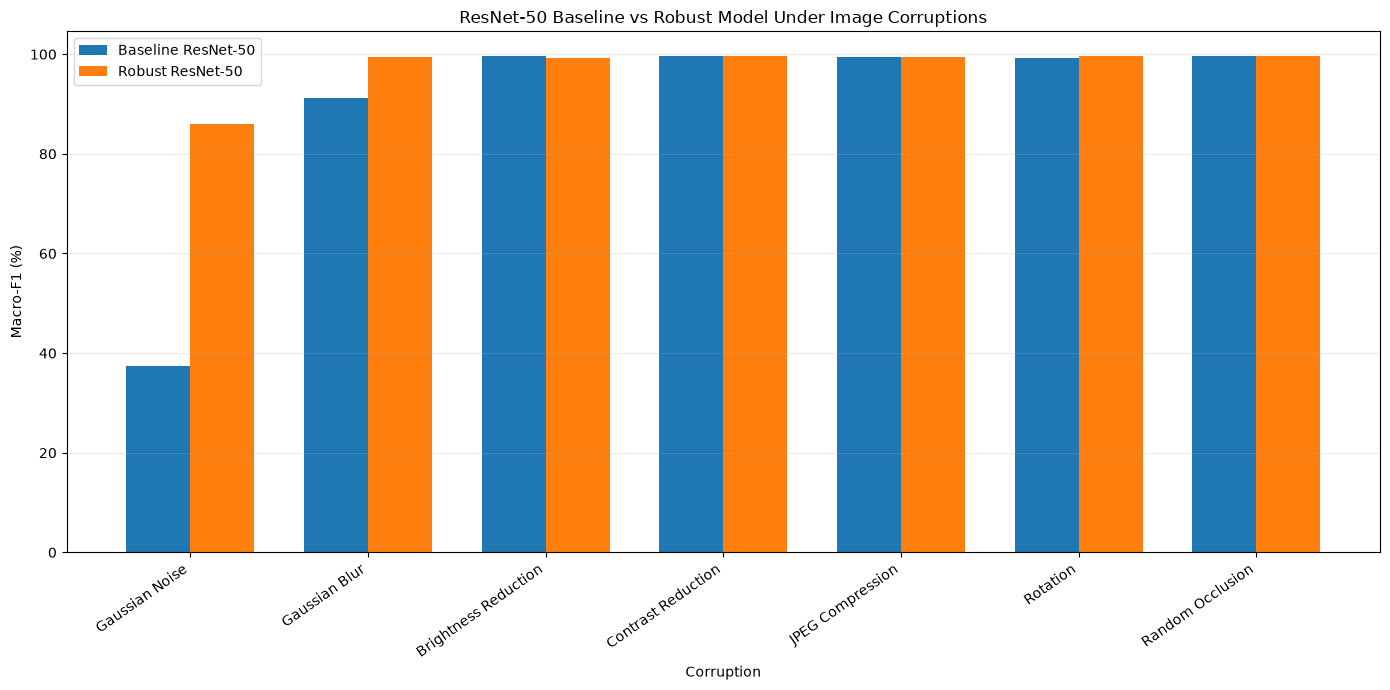


COMPARISON COMPLETE

CSV saved to:
C:\Users\cscpr\Downloads\random 2\results\resnet50_baseline_vs_robust_robustness.csv

Report saved to:
C:\Users\cscpr\Downloads\random 2\results\resnet50_baseline_vs_robust_robustness_report.txt

Plot saved to:
C:\Users\cscpr\Downloads\random 2\results\resnet50_baseline_vs_robust_robustness.png

KEY GAUSSIAN NOISE RESULT
Baseline Accuracy : 38.9837%
Robust Accuracy   : 87.9465%
Difference        : 48.9628 percentage points

Baseline Macro-F1 : 37.4118%
Robust Macro-F1   : 85.9364%
Difference        : 48.5246 percentage points

✓ All results saved successfully.


In [23]:
# ================================================================
# RESNET-50 BASELINE vs ROBUST
# CORRECTED ROBUSTNESS COMPARISON
# ================================================================

import os
import time
import random
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance, ImageFilter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ================================================================
# CONFIGURATION
# ================================================================

SEED = 42

BASE_DIR = r"C:\Users\cscpr\Downloads\random 2"

SPLIT_FILE = os.path.join(
    BASE_DIR,
    "plantvillage_color_stratified_split.csv"
)

BASELINE_CHECKPOINT = os.path.join(
    BASE_DIR,
    "models",
    "resnet50_baseline_best.pth"
)

ROBUST_CHECKPOINT = os.path.join(
    BASE_DIR,
    "models",
    "resnet50_robust_best.pth"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

os.makedirs(RESULTS_DIR, exist_ok=True)


# Output files
CSV_OUTPUT = os.path.join(
    RESULTS_DIR,
    "resnet50_baseline_vs_robust_robustness.csv"
)

REPORT_OUTPUT = os.path.join(
    RESULTS_DIR,
    "resnet50_baseline_vs_robust_robustness_report.txt"
)

PLOT_OUTPUT = os.path.join(
    RESULTS_DIR,
    "resnet50_baseline_vs_robust_robustness.png"
)


# ================================================================
# HYPERPARAMETERS
# ================================================================

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_CLASSES = 38

USE_AMP = torch.cuda.is_available()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ================================================================
# REPRODUCIBILITY
# ================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True


# ================================================================
# PRINT CONFIGURATION
# ================================================================

print("=" * 70)
print("RESNET-50 BASELINE vs ROBUST")
print("CORRECTED ROBUSTNESS COMPARISON")
print("=" * 70)

print(f"Device       : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")

print(f"AMP enabled  : {USE_AMP}")

print()
print("Split file:")
print(SPLIT_FILE)

print()
print("Baseline checkpoint:")
print(BASELINE_CHECKPOINT)

print()
print("Robust checkpoint:")
print(ROBUST_CHECKPOINT)


# ================================================================
# VERIFY FILES
# ================================================================

print()
print("=" * 70)
print("CHECKING FILES")
print("=" * 70)

if not os.path.isfile(SPLIT_FILE):
    raise FileNotFoundError(
        f"Split file not found:\n{SPLIT_FILE}"
    )

if not os.path.isfile(BASELINE_CHECKPOINT):
    raise FileNotFoundError(
        f"Baseline checkpoint not found:\n{BASELINE_CHECKPOINT}"
    )

if not os.path.isfile(ROBUST_CHECKPOINT):
    raise FileNotFoundError(
        f"Robust checkpoint not found:\n{ROBUST_CHECKPOINT}"
    )

print("✓ Split file found")
print("✓ Baseline checkpoint found")
print("✓ Robust checkpoint found")


# ================================================================
# LOAD SPLIT
# ================================================================

print()
print("=" * 70)
print("LOADING TEST SPLIT")
print("=" * 70)

df = pd.read_csv(SPLIT_FILE)

required_columns = {"path", "class_name", "split"}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

test_df = df[df["split"] == "test"].copy()

test_df = test_df.reset_index(drop=True)

print(f"Total rows in split : {len(df):,}")
print(f"Test images         : {len(test_df):,}")


# ================================================================
# CLASS MAPPING
# ================================================================

class_names = sorted(
    df["class_name"].unique().tolist()
)

if len(class_names) != NUM_CLASSES:
    raise ValueError(
        f"Expected {NUM_CLASSES} classes, "
        f"found {len(class_names)}"
    )

class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

idx_to_class = {
    idx: name
    for name, idx in class_to_idx.items()
}

print(f"Classes             : {len(class_names)}")


# ================================================================
# RESOLVE IMAGE PATHS
# ================================================================

print()
print("Checking test image paths...")

missing_paths = []

for path in test_df["path"]:
    if not os.path.isfile(path):
        missing_paths.append(path)

if missing_paths:
    print()
    print("First missing paths:")
    for p in missing_paths[:10]:
        print(p)

    raise FileNotFoundError(
        f"{len(missing_paths)} test image paths could not be resolved."
    )

print("✓ All test image paths resolved.")


# ================================================================
# DATASET
# ================================================================

class PlantVillageDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = row["path"]
        class_name = row["class_name"]

        image = Image.open(
            image_path
        ).convert("RGB")

        label = class_to_idx[class_name]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# ================================================================
# BASE TRANSFORM
# ================================================================

base_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        antialias=True
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ================================================================
# TEST DATASET
# ================================================================

test_dataset = PlantVillageDataset(
    test_df,
    transform=base_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("✓ Test dataset created.")
print(f"Test batches: {len(test_loader)}")


# ================================================================
# CORRUPTION FUNCTIONS
# ================================================================

def apply_corruption(
    image,
    corruption_name
):

    # ------------------------------------------------------------
    # Gaussian Noise
    # ------------------------------------------------------------

    if corruption_name == "gaussian_noise":

        image_np = np.asarray(
            image
        ).astype(np.float32) / 255.0

        noise = np.random.normal(
            loc=0.0,
            scale=0.15,
            size=image_np.shape
        )

        image_np = np.clip(
            image_np + noise,
            0.0,
            1.0
        )

        image_np = (
            image_np * 255
        ).astype(np.uint8)

        return Image.fromarray(image_np)


    # ------------------------------------------------------------
    # Gaussian Blur
    # ------------------------------------------------------------

    elif corruption_name == "gaussian_blur":

        return image.filter(
            ImageFilter.GaussianBlur(
                radius=1.5
            )
        )


    # ------------------------------------------------------------
    # Brightness Reduction
    # ------------------------------------------------------------

    elif corruption_name == "brightness":

        enhancer = ImageEnhance.Brightness(
            image
        )

        return enhancer.enhance(
            0.6
        )


    # ------------------------------------------------------------
    # Contrast Reduction
    # ------------------------------------------------------------

    elif corruption_name == "contrast":

        enhancer = ImageEnhance.Contrast(
            image
        )

        return enhancer.enhance(
            0.6
        )


    # ------------------------------------------------------------
    # JPEG Compression
    # ------------------------------------------------------------

    elif corruption_name == "jpeg_compression":

        import io

        buffer = io.BytesIO()

        image.save(
            buffer,
            format="JPEG",
            quality=30
        )

        buffer.seek(0)

        return Image.open(
            buffer
        ).convert("RGB")


    # ------------------------------------------------------------
    # Rotation
    # ------------------------------------------------------------

    elif corruption_name == "rotation":

        return image.rotate(
            20,
            resample=Image.BILINEAR,
            expand=False,
            fillcolor=(0, 0, 0)
        )


    # ------------------------------------------------------------
    # Random Occlusion
    # ------------------------------------------------------------

    elif corruption_name == "occlusion":

        image = image.copy()

        width, height = image.size

        # Approximately 20% rectangular occlusion
        occ_width = int(width * 0.20)
        occ_height = int(height * 0.20)

        x_max = max(
            1,
            width - occ_width
        )

        y_max = max(
            1,
            height - occ_height
        )

        x = np.random.randint(
            0,
            x_max
        )

        y = np.random.randint(
            0,
            y_max
        )

        # Use black occlusion
        from PIL import ImageDraw

        draw = ImageDraw.Draw(image)

        draw.rectangle(
            [
                x,
                y,
                x + occ_width,
                y + occ_height
            ],
            fill=(0, 0, 0)
        )

        return image


    # ------------------------------------------------------------
    # Clean
    # ------------------------------------------------------------

    elif corruption_name == "clean":

        return image


    else:

        raise ValueError(
            f"Unknown corruption: {corruption_name}"
        )


# ================================================================
# CORRUPTED DATASET
# ================================================================

class CorruptedPlantVillageDataset(Dataset):

    def __init__(
        self,
        dataframe,
        corruption_name,
        transform
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.corruption_name = corruption_name

        self.transform = transform


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = row["path"]

        class_name = row["class_name"]

        image = Image.open(
            image_path
        ).convert("RGB")

        image = apply_corruption(
            image,
            self.corruption_name
        )

        if self.transform is not None:

            image = self.transform(
                image
            )

        label = class_to_idx[
            class_name
        ]

        return image, label


# ================================================================
# MODEL CREATION
# ================================================================

def create_resnet50():

    model = models.resnet50(
        weights=None
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        NUM_CLASSES
    )

    return model.to(DEVICE)


# ================================================================
# CHECKPOINT LOADER
# ================================================================

def load_checkpoint(
    model,
    checkpoint_path
):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE
    )

    # Handle either full checkpoint
    # or direct state_dict

    if isinstance(
        checkpoint,
        dict
    ) and "model_state_dict" in checkpoint:

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        epoch = checkpoint.get(
            "epoch",
            None
        )

        val_macro_f1 = checkpoint.get(
            "val_macro_f1",
            None
        )

    else:

        model.load_state_dict(
            checkpoint
        )

        epoch = None

        val_macro_f1 = None

    return model, epoch, val_macro_f1


# ================================================================
# EVALUATION FUNCTION
# ================================================================

def evaluate_model(
    model,
    corruption_name
):

    dataset = CorruptedPlantVillageDataset(
        test_df,
        corruption_name,
        base_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    criterion = nn.CrossEntropyLoss()

    model.eval()

    all_predictions = []
    all_labels = []

    total_loss = 0.0
    total_samples = 0

    start_time = time.time()

    scaler_context = (
        torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP
        )
        if DEVICE.type == "cuda"
        else torch.autocast(
            device_type="cpu",
            enabled=False
        )
    )

    with torch.no_grad():

        for batch_idx, (
            images,
            labels
        ) in enumerate(loader):

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            if DEVICE.type == "cuda":

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16,
                    enabled=USE_AMP
                ):

                    outputs = model(
                        images
                    )

                    loss = criterion(
                        outputs,
                        labels
                    )

            else:

                outputs = model(
                    images
                )

                loss = criterion(
                    outputs,
                    labels
                )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            batch_size = labels.size(0)

            total_loss += (
                loss.item()
                * batch_size
            )

            total_samples += batch_size

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            if (
                (batch_idx + 1) % 50 == 0
                or
                (batch_idx + 1) == len(loader)
            ):

                print(
                    f"   {batch_idx + 1}/"
                    f"{len(loader)} batches"
                )

    elapsed = time.time() - start_time

    all_labels = np.asarray(
        all_labels
    )

    all_predictions = np.asarray(
        all_predictions
    )

    loss_value = (
        total_loss /
        total_samples
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "loss": loss_value,
        "accuracy": accuracy * 100,
        "balanced_accuracy": balanced_accuracy * 100,
        "macro_f1": macro_f1 * 100,
        "weighted_f1": weighted_f1 * 100,
        "inference_time_seconds": elapsed
    }


# ================================================================
# CORRUPTIONS
# ================================================================

CORRUPTIONS = [
    ("clean", "Clean"),
    ("gaussian_noise", "Gaussian Noise"),
    ("gaussian_blur", "Gaussian Blur"),
    ("brightness", "Brightness Reduction"),
    ("contrast", "Contrast Reduction"),
    ("jpeg_compression", "JPEG Compression"),
    ("rotation", "Rotation"),
    ("occlusion", "Random Occlusion")
]


# ================================================================
# LOAD BOTH MODELS
# ================================================================

print()
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print()
print("Creating baseline ResNet-50...")

baseline_model = create_resnet50()

baseline_model, baseline_epoch, baseline_val_f1 = load_checkpoint(
    baseline_model,
    BASELINE_CHECKPOINT
)

print("✓ Baseline checkpoint loaded.")

print(
    f"Baseline checkpoint epoch : "
    f"{baseline_epoch}"
)

print(
    f"Baseline Val Macro-F1      : "
    f"{baseline_val_f1}"
)


print()
print("Creating robust ResNet-50...")

robust_model = create_resnet50()

robust_model, robust_epoch, robust_val_f1 = load_checkpoint(
    robust_model,
    ROBUST_CHECKPOINT
)

print("✓ Robust checkpoint loaded.")

print(
    f"Robust checkpoint epoch : "
    f"{robust_epoch}"
)

print(
    f"Robust Val Macro-F1     : "
    f"{robust_val_f1}"
)


# ================================================================
# RUN COMPARISON
# ================================================================

all_results = []

for corruption_key, corruption_label in CORRUPTIONS:

    print()
    print("=" * 70)
    print(
        f"CORRUPTION: {corruption_label}"
    )
    print("=" * 70)


    # ------------------------------------------------------------
    # BASELINE
    # ------------------------------------------------------------

    print()
    print(">>> BASELINE RESNET-50")

    baseline_result = evaluate_model(
        baseline_model,
        corruption_key
    )

    print(
        f"Accuracy          : "
        f"{baseline_result['accuracy']:.4f}%"
    )

    print(
        f"Balanced Accuracy : "
        f"{baseline_result['balanced_accuracy']:.4f}%"
    )

    print(
        f"Macro-F1          : "
        f"{baseline_result['macro_f1']:.4f}%"
    )


    # ------------------------------------------------------------
    # ROBUST
    # ------------------------------------------------------------

    print()
    print(">>> ROBUST RESNET-50")

    robust_result = evaluate_model(
        robust_model,
        corruption_key
    )

    print(
        f"Accuracy          : "
        f"{robust_result['accuracy']:.4f}%"
    )

    print(
        f"Balanced Accuracy : "
        f"{robust_result['balanced_accuracy']:.4f}%"
    )

    print(
        f"Macro-F1          : "
        f"{robust_result['macro_f1']:.4f}%"
    )


    # ------------------------------------------------------------
    # BASELINE DROP
    # ------------------------------------------------------------

    # These are filled after the clean result is available.
    result = {
        "corruption": corruption_label,

        "baseline_loss":
            baseline_result["loss"],

        "baseline_accuracy":
            baseline_result["accuracy"],

        "baseline_balanced_accuracy":
            baseline_result["balanced_accuracy"],

        "baseline_macro_f1":
            baseline_result["macro_f1"],

        "baseline_weighted_f1":
            baseline_result["weighted_f1"],

        "baseline_inference_time_seconds":
            baseline_result[
                "inference_time_seconds"
            ],

        "robust_loss":
            robust_result["loss"],

        "robust_accuracy":
            robust_result["accuracy"],

        "robust_balanced_accuracy":
            robust_result["balanced_accuracy"],

        "robust_macro_f1":
            robust_result["macro_f1"],

        "robust_weighted_f1":
            robust_result["weighted_f1"],

        "robust_inference_time_seconds":
            robust_result[
                "inference_time_seconds"
            ],

        "accuracy_improvement_robust_minus_baseline":
            robust_result["accuracy"]
            - baseline_result["accuracy"],

        "balanced_accuracy_improvement_robust_minus_baseline":
            robust_result["balanced_accuracy"]
            - baseline_result["balanced_accuracy"],

        "macro_f1_improvement_robust_minus_baseline":
            robust_result["macro_f1"]
            - baseline_result["macro_f1"],

        "weighted_f1_improvement_robust_minus_baseline":
            robust_result["weighted_f1"]
            - baseline_result["weighted_f1"]
    }

    all_results.append(result)


# ================================================================
# CREATE RESULTS DATAFRAME
# ================================================================

results_df = pd.DataFrame(
    all_results
)


# ================================================================
# CALCULATE DROPS FROM CLEAN
# ================================================================

baseline_clean = results_df.loc[
    results_df["corruption"] == "Clean"
].iloc[0]

robust_clean = results_df.loc[
    results_df["corruption"] == "Clean"
].iloc[0]


results_df[
    "baseline_accuracy_drop"
] = (
    baseline_clean["baseline_accuracy"]
    - results_df["baseline_accuracy"]
)

results_df[
    "baseline_macro_f1_drop"
] = (
    baseline_clean["baseline_macro_f1"]
    - results_df["baseline_macro_f1"]
)


results_df[
    "robust_accuracy_drop"
] = (
    robust_clean["robust_accuracy"]
    - results_df["robust_accuracy"]
)

results_df[
    "robust_macro_f1_drop"
] = (
    robust_clean["robust_macro_f1"]
    - results_df["robust_macro_f1"]
)


# ================================================================
# SAVE CSV
# ================================================================

results_df.to_csv(
    CSV_OUTPUT,
    index=False
)


# ================================================================
# PRINT MAIN RESULTS
# ================================================================

print()
print("=" * 70)
print("FINAL BASELINE vs ROBUST RESULTS")
print("=" * 70)

display_columns = [
    "corruption",
    "baseline_accuracy",
    "robust_accuracy",
    "accuracy_improvement_robust_minus_baseline",
    "baseline_macro_f1",
    "robust_macro_f1",
    "macro_f1_improvement_robust_minus_baseline"
]

print(
    results_df[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ================================================================
# FIND WORST CONDITIONS
# ================================================================

baseline_nonclean = results_df[
    results_df["corruption"] != "Clean"
]

robust_nonclean = results_df[
    results_df["corruption"] != "Clean"
]


baseline_worst = baseline_nonclean.loc[
    baseline_nonclean[
        "baseline_macro_f1_drop"
    ].idxmax()
]

robust_worst = robust_nonclean.loc[
    robust_nonclean[
        "robust_macro_f1_drop"
    ].idxmax()
]


# ================================================================
# FIND BEST ROBUST IMPROVEMENT
# ================================================================

best_accuracy_improvement = results_df.loc[
    results_df[
        "accuracy_improvement_robust_minus_baseline"
    ].idxmax()
]

best_macro_f1_improvement = results_df.loc[
    results_df[
        "macro_f1_improvement_robust_minus_baseline"
    ].idxmax()
]


# ================================================================
# GAUSSIAN NOISE SPECIFIC COMPARISON
# ================================================================

gaussian_noise = results_df[
    results_df["corruption"] == "Gaussian Noise"
].iloc[0]


# ================================================================
# REPORT
# ================================================================

report_lines = []

report_lines.append(
    "=" * 70
)

report_lines.append(
    "RESNET-50 BASELINE vs ROBUST"
)

report_lines.append(
    "CORRECTED ROBUSTNESS COMPARISON"
)

report_lines.append(
    "=" * 70
)

report_lines.append("")

report_lines.append(
    f"Test images : {len(test_df):,}"
)

report_lines.append(
    f"Classes     : {len(class_names)}"
)

report_lines.append("")

report_lines.append(
    f"Baseline checkpoint epoch : "
    f"{baseline_epoch}"
)

report_lines.append(
    f"Baseline Val Macro-F1      : "
    f"{baseline_val_f1}"
)

report_lines.append("")

report_lines.append(
    f"Robust checkpoint epoch : "
    f"{robust_epoch}"
)

report_lines.append(
    f"Robust Val Macro-F1     : "
    f"{robust_val_f1}"
)

report_lines.append("")


# ------------------------------------------------------------
# CLEAN
# ------------------------------------------------------------

report_lines.append(
    "=" * 70
)

report_lines.append(
    "CLEAN TEST COMPARISON"
)

report_lines.append(
    "=" * 70
)

report_lines.append("")

report_lines.append(
    f"Baseline Accuracy : "
    f"{baseline_clean['baseline_accuracy']:.4f}%"
)

report_lines.append(
    f"Robust Accuracy   : "
    f"{robust_clean['robust_accuracy']:.4f}%"
)

report_lines.append("")

report_lines.append(
    f"Baseline Macro-F1 : "
    f"{baseline_clean['baseline_macro_f1']:.4f}%"
)

report_lines.append(
    f"Robust Macro-F1   : "
    f"{robust_clean['robust_macro_f1']:.4f}%"
)

report_lines.append("")


# ------------------------------------------------------------
# GAUSSIAN NOISE
# ------------------------------------------------------------

report_lines.append(
    "=" * 70
)

report_lines.append(
    "GAUSSIAN NOISE COMPARISON"
)

report_lines.append(
    "=" * 70
)

report_lines.append("")

report_lines.append(
    f"Baseline Accuracy : "
    f"{gaussian_noise['baseline_accuracy']:.4f}%"
)

report_lines.append(
    f"Robust Accuracy   : "
    f"{gaussian_noise['robust_accuracy']:.4f}%"
)

report_lines.append(
    f"Improvement       : "
    f"{gaussian_noise['accuracy_improvement_robust_minus_baseline']:.4f} "
    f"percentage points"
)

report_lines.append("")

report_lines.append(
    f"Baseline Macro-F1 : "
    f"{gaussian_noise['baseline_macro_f1']:.4f}%"
)

report_lines.append(
    f"Robust Macro-F1   : "
    f"{gaussian_noise['robust_macro_f1']:.4f}%"
)

report_lines.append(
    f"Improvement       : "
    f"{gaussian_noise['macro_f1_improvement_robust_minus_baseline']:.4f} "
    f"percentage points"
)

report_lines.append("")


# ------------------------------------------------------------
# WORST CONDITIONS
# ------------------------------------------------------------

report_lines.append(
    "=" * 70
)

report_lines.append(
    "WORST ROBUSTNESS CONDITIONS"
)

report_lines.append(
    "=" * 70
)

report_lines.append("")

report_lines.append(
    f"Baseline worst condition : "
    f"{baseline_worst['corruption']}"
)

report_lines.append(
    f"Baseline Macro-F1        : "
    f"{baseline_worst['baseline_macro_f1']:.4f}%"
)

report_lines.append(
    f"Baseline Macro-F1 drop   : "
    f"{baseline_worst['baseline_macro_f1_drop']:.4f} "
    f"percentage points"
)

report_lines.append("")

report_lines.append(
    f"Robust worst condition   : "
    f"{robust_worst['corruption']}"
)

report_lines.append(
    f"Robust Macro-F1          : "
    f"{robust_worst['robust_macro_f1']:.4f}%"
)

report_lines.append(
    f"Robust Macro-F1 drop     : "
    f"{robust_worst['robust_macro_f1_drop']:.4f} "
    f"percentage points"
)

report_lines.append("")


# ------------------------------------------------------------
# BEST IMPROVEMENT
# ------------------------------------------------------------

report_lines.append(
    "=" * 70
)

report_lines.append(
    "ROBUST MODEL IMPROVEMENT"
)

report_lines.append(
    "=" * 70
)

report_lines.append("")

report_lines.append(
    f"Best Accuracy improvement : "
    f"{best_accuracy_improvement['corruption']}"
)

report_lines.append(
    f"Accuracy improvement      : "
    f"{best_accuracy_improvement['accuracy_improvement_robust_minus_baseline']:.4f} "
    f"percentage points"
)

report_lines.append("")

report_lines.append(
    f"Best Macro-F1 improvement : "
    f"{best_macro_f1_improvement['corruption']}"
)

report_lines.append(
    f"Macro-F1 improvement      : "
    f"{best_macro_f1_improvement['macro_f1_improvement_robust_minus_baseline']:.4f} "
    f"percentage points"
)

report_lines.append("")


# ------------------------------------------------------------
# FULL TABLE
# ------------------------------------------------------------

report_lines.append(
    "=" * 70
)

report_lines.append(
    "FULL RESULTS"
)

report_lines.append(
    "=" * 70
)

report_lines.append("")

report_lines.append(
    results_df[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

report_lines.append("")


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------

report_lines.append(
    "=" * 70
)

report_lines.append(
    "INTERPRETATION"
)

report_lines.append(
    "=" * 70
)

report_lines.append("")

noise_improvement = (
    gaussian_noise[
        "macro_f1_improvement_robust_minus_baseline"
    ]
)

if noise_improvement > 0:

    report_lines.append(
        "The robust model improved Macro-F1 under "
        "Gaussian Noise compared with the baseline."
    )

elif noise_improvement < 0:

    report_lines.append(
        "The robust model did not improve Macro-F1 "
        "under Gaussian Noise compared with the baseline."
    )

else:

    report_lines.append(
        "The robust and baseline models achieved the "
        "same Macro-F1 under Gaussian Noise."
    )


overall_improvement = results_df[
    results_df["corruption"] != "Clean"
][
    "macro_f1_improvement_robust_minus_baseline"
].mean()


report_lines.append("")

report_lines.append(
    f"Mean Macro-F1 improvement across corruptions "
    f"(excluding clean): {overall_improvement:.4f} "
    f"percentage points."
)

report_lines.append("")

report_lines.append(
    "Clean-test performance should be interpreted separately "
    "from corruption robustness. The principal purpose of "
    "this comparison is to determine whether robust training "
    "reduces performance degradation under image corruptions."
)

report_lines.append("")

report_lines.append(
    "✓ Corrected robustness comparison completed."
)


with open(
    REPORT_OUTPUT,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "\n".join(report_lines)
    )


# ================================================================
# PLOT
# ================================================================

plot_df = results_df.copy()

# Remove clean for robustness visualization
plot_df = plot_df[
    plot_df["corruption"] != "Clean"
].copy()


x = np.arange(
    len(plot_df)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(14, 7)
)

ax.bar(
    x - width / 2,
    plot_df["baseline_macro_f1"],
    width,
    label="Baseline ResNet-50"
)

ax.bar(
    x + width / 2,
    plot_df["robust_macro_f1"],
    width,
    label="Robust ResNet-50"
)

ax.set_ylabel(
    "Macro-F1 (%)"
)

ax.set_xlabel(
    "Corruption"
)

ax.set_title(
    "ResNet-50 Baseline vs Robust Model Under Image Corruptions"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    plot_df["corruption"],
    rotation=35,
    ha="right"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    PLOT_OUTPUT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# FINAL OUTPUT
# ================================================================

print()
print("=" * 70)
print("COMPARISON COMPLETE")
print("=" * 70)

print()
print("CSV saved to:")
print(CSV_OUTPUT)

print()
print("Report saved to:")
print(REPORT_OUTPUT)

print()
print("Plot saved to:")
print(PLOT_OUTPUT)

print()
print("=" * 70)
print("KEY GAUSSIAN NOISE RESULT")
print("=" * 70)

print(
    f"Baseline Accuracy : "
    f"{gaussian_noise['baseline_accuracy']:.4f}%"
)

print(
    f"Robust Accuracy   : "
    f"{gaussian_noise['robust_accuracy']:.4f}%"
)

print(
    f"Difference        : "
    f"{gaussian_noise['accuracy_improvement_robust_minus_baseline']:.4f} "
    f"percentage points"
)

print()

print(
    f"Baseline Macro-F1 : "
    f"{gaussian_noise['baseline_macro_f1']:.4f}%"
)

print(
    f"Robust Macro-F1   : "
    f"{gaussian_noise['robust_macro_f1']:.4f}%"
)

print(
    f"Difference        : "
    f"{gaussian_noise['macro_f1_improvement_robust_minus_baseline']:.4f} "
    f"percentage points"
)

print()
print("✓ All results saved successfully.")